In [28]:
%pip install requests
%pip install matplotlib


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\marti\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     -------------------------------------- - 51.2/52.8 kB 1.3 MB/s eta 0:00:01
     -------------------------------------- 52.8/52.8 kB 925.9 kB/s eta 0:00:00
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/119.6 kB ? eta -:--:--
     -------------------------------------- 119.6/119.6 kB 7.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB 9.6 MB/s eta 0:00:01
   ---- ----------------------------------- 1.0/8.1 MB 10.8 MB/s eta 0:00:01
   ------- -------------------------------- 1.5/8.1 MB 11.0 MB/s eta 0:00:01
   ---------- ----------------------------- 2.0/8.1 MB 10.8 MB/s eta 0:00:01
   ------------ --------------------------- 2.6/8.1 MB 11.0 MB/s eta 0:00:01
   --------------- ------------------------ 3.1/8.1 MB 11.1 MB/s eta 0:00:01
   ------------------


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\marti\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import requests
import time

df = pd.read_csv("person_names.csv")

In [ ]:
import pandas as pd
import requests
import time

df = pd.read_csv("person_names.csv")

# Headers necesarios para que Wikidata acepte las solicitudes
HEADERS = {
    'User-Agent': 'DataMiningProject/1.0 (Educational Purpose)',
    'Accept': 'application/json'
}

def clean_name(name):
    """Limpia el nombre eliminando ' & family' y otros sufijos"""
    name = name.replace(" & family", "")
    name = name.strip()
    return name

def is_business_person(entity_data, entity_id):
    """Verifica si la entidad es un empresario/billonario"""
    claims = entity_data["entities"][entity_id].get("claims", {})
    
    # P106 = occupation (ocupación)
    if "P106" in claims:
        for claim in claims["P106"]:
            try:
                occupation_id = claim["mainsnak"]["datavalue"]["value"]["id"]
                # IDs relevantes: Q131524=entrepreneur, Q43845=businessperson, Q140686=chairperson
                # Q484876=CEO, Q1273818=investor, Q205375=philanthropist
                if occupation_id in ["Q131524", "Q43845", "Q140686", "Q484876", "Q1273818", "Q205375"]:
                    return True
            except (KeyError, TypeError):
                continue
    
    # Verificar descripción
    descriptions = entity_data["entities"][entity_id].get("descriptions", {})
    desc_en = descriptions.get("en", {}).get("value", "").lower()
    business_keywords = ["business", "entrepreneur", "billionaire", "investor", "ceo", "founder"]
    if any(keyword in desc_en for keyword in business_keywords):
        return True
    
    return False

def get_company_count(name, max_retries=3):
    """Obtiene el número de compañías asociadas a una persona desde Wikidata"""
    
    # Limpiar el nombre
    clean = clean_name(name)
    
    for attempt in range(max_retries):
        try:
            # Paso 1: Buscar la entidad de la persona (buscar más resultados)
            search_url = "https://www.wikidata.org/w/api.php"
            search_params = {
                "action": "wbsearchentities",
                "search": clean,
                "language": "en",
                "format": "json",
                "type": "item",
                "limit": 5  # Buscar hasta 5 resultados
            }
            
            search_response = requests.get(
                search_url, 
                params=search_params, 
                headers=HEADERS,
                timeout=30
            )
            search_response.raise_for_status()
            search_data = search_response.json()
            
            if not search_data.get("search"):
                print(f"  ⚠️ No se encontró entidad para: {clean}")
                return 0
            
            # Intentar encontrar la persona correcta (empresario/billonario)
            entity_id = None
            label = None
            
            for result in search_data["search"]:
                candidate_id = result["id"]
                candidate_label = result.get('label', '')
                candidate_desc = result.get('description', '').lower()
                
                # Verificar si la descripción sugiere que es un empresario
                business_keywords = ["business", "entrepreneur", "billionaire", "investor", "ceo", "founder", "chairperson"]
                if any(keyword in candidate_desc for keyword in business_keywords):
                    entity_id = candidate_id
                    label = candidate_label
                    print(f"  ✓ Encontrado: {entity_id} - {label} ({candidate_desc})")
                    break
            
            # Si no encontramos uno obvio, usar el primero
            if not entity_id:
                entity_id = search_data["search"][0]["id"]
                label = search_data["search"][0].get('label', '')
                print(f"  ⚠️ Usando primer resultado: {entity_id} - {label}")
            
            # Paso 2: Obtener datos de la entidad
            entity_url = f"https://www.wikidata.org/wiki/Special:EntityData/{entity_id}.json"
            entity_response = requests.get(
                entity_url, 
                headers=HEADERS,
                timeout=30
            )
            entity_response.raise_for_status()
            entity_data = entity_response.json()
            
            claims = entity_data["entities"][entity_id].get("claims", {})
            
            # Verificar si es empresario (ayuda a confirmar identidad)
            if is_business_person(entity_data, entity_id):
                print(f"  ✓ Confirmado como empresario/inversor")
            
            # Propiedades de Wikidata relacionadas con compañías (expandidas)
            company_properties = {
                "P112": "founder of",           # fundador de
                "P169": "chief executive officer", # CEO de
                "P488": "chairperson",          # presidente de
                "P1037": "director/manager",    # director/gerente de
                "P108": "employer",             # empleador
                "P1830": "owner of",            # propietario/inversor de
                "P127": "owned by",             # propiedad de (inverso, para verificar)
                "P1454": "legal form",          # forma legal (para holdings)
                "P749": "parent organization",  # organización matriz
                "P102": "member of political party"  # a veces relevante para magnates
            }
            
            companies = set()
            property_counts = {}
            
            # Recolectar todas las compañías/organizaciones
            for prop_id, prop_name in company_properties.items():
                if prop_id in claims:
                    prop_count = 0
                    for claim in claims[prop_id]:
                        try:
                            # Obtener el ID de la compañía
                            company_id = claim["mainsnak"]["datavalue"]["value"]["id"]
                            companies.add(company_id)
                            prop_count += 1
                        except (KeyError, TypeError):
                            continue
                    if prop_count > 0:
                        property_counts[prop_name] = prop_count
            
            count = len(companies)
            
            # Logging detallado
            if count > 0:
                print(f"  → Compañías encontradas: {count}")
                if property_counts:
                    print(f"     Desglose: {', '.join([f'{k}: {v}' for k, v in property_counts.items()])}")
            else:
                print(f"  ⚠️ 0 compañías - revisar manualmente")
            
            return count
            
        except requests.exceptions.Timeout:
            if attempt < max_retries - 1:
                print(f"  ⏱ Timeout, reintentando ({attempt + 1}/{max_retries})...")
                time.sleep(2)
                continue
            else:
                print(f"  ✗ Timeout después de {max_retries} intentos")
                return 0
                
        except requests.exceptions.RequestException as e:
            if attempt < max_retries - 1:
                print(f"  ⚠️ Error: {str(e)[:50]}, reintentando...")
                time.sleep(2)
                continue
            else:
                print(f"  ✗ Error de conexión: {str(e)[:100]}")
                return 0
                
        except Exception as e:
            print(f"  ✗ Error: {str(e)[:100]}")
            return 0
    
    return 0


# Verificar conexión primero
print("Verificando conexión a Wikidata...")
try:
    test_response = requests.get(
        "https://www.wikidata.org/w/api.php?action=wbsearchentities&search=test&language=en&format=json",
        headers=HEADERS,
        timeout=15
    )
    if test_response.status_code == 200:
        print("✓ Conexión exitosa\n")
    else:
        print(f"⚠️ Código de respuesta: {test_response.status_code}\n")
except Exception as e:
    print(f"✗ Error de conexión: {e}")
    print("Verifica tu conexión a internet o proxy\n")

# Procesar cada nombre
results = []

print("Buscando compañías para cada persona...\n")

for idx, name in enumerate(df["personName"], 1):
    print(f"{idx}. {name}")
    
    count = get_company_count(name)
    results.append(count)
    
    # Pausa para no sobrecargar la API
    time.sleep(1.5)
    print()

# Guardar resultados
df["numberOfCompanies"] = results

df[["personName", "numberOfCompanies"]].to_csv(
    "person_companies.csv",
    index=False
)

print("✓ Resultados guardados en 'person_companies.csv'")
print(f"\nResumen:")
print(df[["personName", "numberOfCompanies"]])

Verificando conexión a Wikidata...
✓ Conexión exitosa

Buscando compañías para cada persona...

1. Bernard Arnault & family
  ✓ Encontrado: Q32055 - Bernard Arnault (french entrepreneur)
  ✓ Confirmado como empresario/inversor
  ⚠️ 0 compañías - revisar manualmente

2. Elon Musk
  ✓ Encontrado: Q317521 - Elon Musk (businessman and entrepreneur (born 1971))
  ✓ Confirmado como empresario/inversor
  → Compañías encontradas: 15
     Desglose: employer: 8, owner of: 9, member of political party: 1

3. Jeff Bezos
  ✓ Encontrado: Q312556 - Jeff Bezos (american business magnate (born 1964))
  ✓ Confirmado como empresario/inversor
  → Compañías encontradas: 6
     Desglose: employer: 4, owner of: 3

4. Larry Ellison
  ✓ Encontrado: Q92759 - Larry Ellison (american internet entrepreneur and businessman (born 1944))
  ✓ Confirmado como empresario/inversor
  → Compañías encontradas: 9
     Desglose: employer: 2, owner of: 7

5. Warren Buffett
  ✓ Encontrado: Q47213 - Warren Buffett (american inve

Datos cargados:
                  personName  numberOfCompanies
0   Bernard Arnault & family                  0
1                  Elon Musk                 14
2                 Jeff Bezos                  6
3              Larry Ellison                  9
4             Warren Buffett                  1
5                 Bill Gates                  6
6          Michael Bloomberg                  2
7  Carlos Slim Helu & family                  6
8              Mukesh Ambani                  5
9              Steve Ballmer                  2

Total de registros: 2640

--- Estadísticas del número de empresas ---
count    2640.000000
mean        0.343939
std         1.154542
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        32.000000
Name: numberOfCompanies, dtype: float64

--- Distribución de frecuencia ---
numberOfCompanies
0     2153
1      306
2       92
3       44
4       16
5       10
6       11
8        3
9        1
13       1
14       2
32

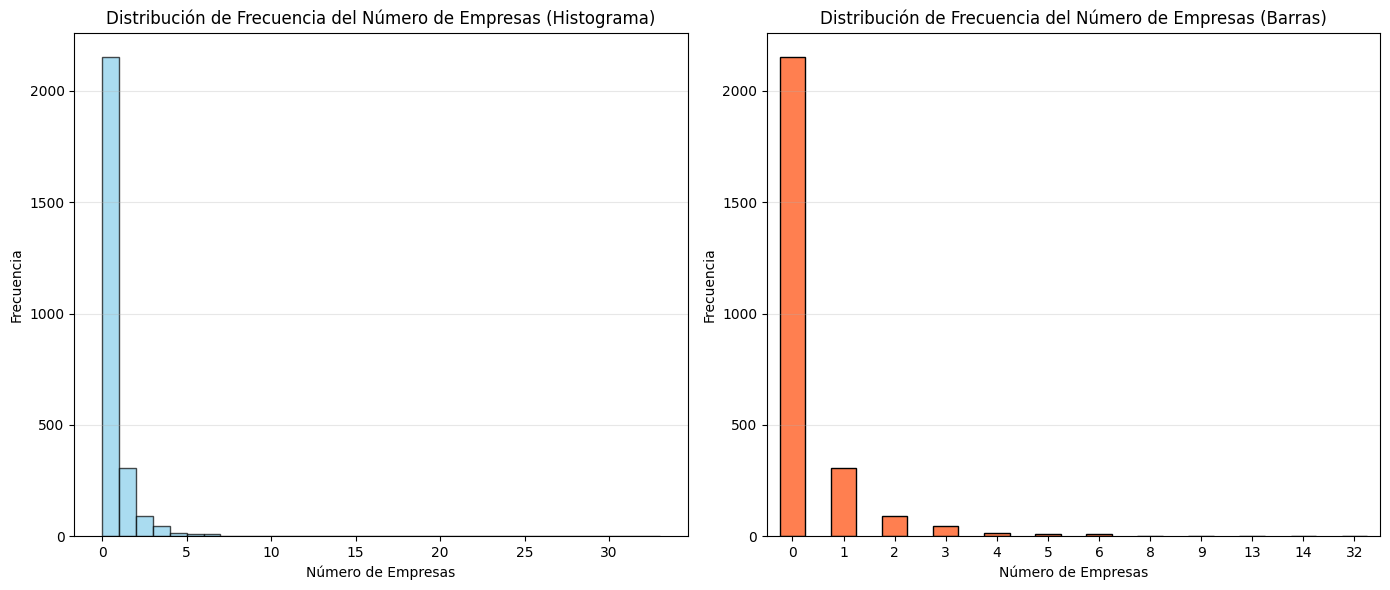


--- Top 10 personas con más empresas ---
               personName  numberOfCompanies
           Rinat Akhmetov                 32
                Elon Musk                 14
              Josh Harris                 14
Roman Abramovich & family                 13
            Larry Ellison                  9
              Meg Whitman                  8
                    Jay-Z                  8
             Donald Trump                  8
               Jeff Bezos                  6
               Bill Gates                  6


In [29]:
# Importar person_companies.csv y visualizar distribución de frecuencia
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Leer el archivo
person_companies_df = pd.read_csv("person_companies.csv")

print("Datos cargados:")
print(person_companies_df.head(10))
print(f"\nTotal de registros: {len(person_companies_df)}")

# Estadísticas del número de empresas
print("\n--- Estadísticas del número de empresas ---")
print(person_companies_df['numberOfCompanies'].describe())

# Distribución de frecuencia
print("\n--- Distribución de frecuencia ---")
freq_dist = person_companies_df['numberOfCompanies'].value_counts().sort_index()
print(freq_dist)

# Visualización 1: Histograma
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.hist(person_companies_df['numberOfCompanies'], bins=range(0, person_companies_df['numberOfCompanies'].max() + 2), 
         edgecolor='black', color='skyblue', alpha=0.7)
plt.xlabel('Número de Empresas')
plt.ylabel('Frecuencia')
plt.title('Distribución de Frecuencia del Número de Empresas (Histograma)')
plt.grid(axis='y', alpha=0.3)

# Visualización 2: Gráfico de barras
plt.subplot(1, 2, 2)
freq_dist.plot(kind='bar', color='coral', edgecolor='black')
plt.xlabel('Número de Empresas')
plt.ylabel('Frecuencia')
plt.title('Distribución de Frecuencia del Número de Empresas (Barras)')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Mostrar personas con más empresas
print("\n--- Top 10 personas con más empresas ---")
top_10 = person_companies_df.nlargest(10, 'numberOfCompanies')
print(top_10.to_string(index=False))

In [30]:
person_companies_df.head()

,personName,numberOfCompanies
0,Bernard Arnault & family,0
1,Elon Musk,14
2,Jeff Bezos,6
3,Larry Ellison,9
4,Warren Buffett,1


In [31]:
companies_count = person_companies_df['numberOfCompanies'].value_counts().sort_index()
print(companies_count)

numberOfCompanies
0     2153
1      306
2       92
3       44
4       16
5       10
6       11
8        3
9        1
13       1
14       2
32       1
Name: count, dtype: int64


# GPTo

In [1]:
people_companies = {
    "Bernard Arnault & family": 1,  # LVMH
    "Elon Musk": 5,  # Tesla, SpaceX, X (Twitter), Neuralink, The Boring Company
    "Jeff Bezos": 3,  # Amazon, Blue Origin, The Washington Post
    "Larry Ellison": 2,  # Oracle, Tesla (major investor/board previously)
    "Warren Buffett": 1,  # Berkshire Hathaway
    "Bill Gates": 2,  # Microsoft, Cascade Investment
    "Michael Bloomberg": 1,  # Bloomberg LP
    "Carlos Slim Helu & family": 3,  # América Móvil, Grupo Carso, Grupo Financiero Inbursa
    "Mukesh Ambani": 1,  # Reliance Industries
    "Steve Ballmer": 2,  # Microsoft, Los Angeles Clippers
    "Francoise Bettencourt Meyers & family": 1,  # L'Oréal
    "Larry Page": 1,  # Alphabet (Google)
    "Amancio Ortega": 1,  # Inditex
    "Sergey Brin": 1,  # Alphabet (Google)
    "Zhong Shanshan": 2,  # Nongfu Spring, Beijing Wantai Biological
    "Mark Zuckerberg": 1,  # Meta
    "Charles Koch & family": 1,  # Koch Industries
    "Julia Koch & family": 1,  # Koch Industries
    "Jim Walton": 1,  # Walmart
    "Rob Walton & family": 1,  # Walmart
    "Alice Walton": 1,  # Walmart
    "David Thomson & family": 1,  # Thomson Reuters
    "Michael Dell": 2,  # Dell Technologies, MSD Capital
    "Gautam Adani": 1,  # Adani Group
    "Phil Knight & family": 1,  # Nike
    "Zhang Yiming": 1,  # ByteDance
    "Dieter Schwarz": 1,  # Schwarz Group (Lidl, Kaufland)
    "François Pinault & family": 1,  # Kering
    "Klaus-Michael Kuehne": 1,  # Kühne + Nagel
    "Giovanni Ferrero": 1,  # Ferrero Group
    "Jacqueline Mars": 1,  # Mars Inc.
    "John Mars": 1,  # Mars Inc.
    "Li Ka-shing": 2,  # CK Hutchison Holdings, CK Asset Holdings
    "Ma Huateng": 1,  # Tencent
    "Miriam Adelson & family": 1,  # Las Vegas Sands
    "Ken Griffin": 1,  # Citadel
    "Mark Mateschitz": 1,  # Red Bull
    "Robin Zeng": 1,  # CATL
    "Tadashi Yanai & family": 1,  # Fast Retailing (Uniqlo)
    "Len Blavatnik": 2,  # Access Industries, Warner Music Group
    "Alain Wertheimer": 1,  # Chanel
    "Gerard Wertheimer": 1,  # Chanel
    "Gianluigi Aponte": 1,  # MSC (Mediterranean Shipping Company)
    "Rafaela Aponte-Diamant": 1,  # MSC (Mediterranean Shipping Company)
    "Colin Zheng Huang": 1,  # PDD Holdings (Pinduoduo)
    "Reinhold Wuerth & family": 1,  # Würth Group
    "Lee Shau Kee": 1,  # Henderson Land Development
    "Jeff Yass": 1,  # Susquehanna International Group
    "Jim Simons": 1,  # Renaissance Technologies
    "Stephen Schwarzman": 1,  # Blackstone
    "Susanne Klatten": 1,  # BMW
    "Gina Rinehart": 1,  # Hancock Prospecting
    "William Ding": 1,  # NetEase
    "Germán Larrea Mota Velasco & family": 1,  # Grupo México
    "Shiv Nadar": 1,  # HCL Technologies
    "Low Tuck Kwong": 1,  # Bayan Resources
    "Thomas Peterffy": 1,  # Interactive Brokers
    "Andrey Melnichenko & family": 2,  # EuroChem, SUEK
    "Stefan Quandt": 1,  # BMW
    "MacKenzie Scott": 1,  # Amazon (stake)
    "R. Budi Hartono": 1,  # Djarum Group
    "Vladimir Potanin": 1,  # Norilsk Nickel
    "Jack Ma": 1,  # Alibaba Group
    "He Xiangjian & family": 1,  # Midea Group
    "Iris Fontbona & family": 1,  # Antofagasta PLC
    "Michael Hartono": 1,  # Djarum Group
    "James Ratcliffe": 1,  # INEOS
    "Cyrus Poonawalla": 1,  # Serum Institute of India
    "Masayoshi Son": 1,  # SoftBank
    "Vladimir Lisin": 1,  # NLMK Group
    "Emmanuel Besnier": 1,  # Lactalis
    "Abigail Johnson": 1,  # Fidelity Investments
    "Leonid Mikhelson & family": 1,  # Novatek
    "Lukas Walton": 1,  # Walmart (family wealth)
    "Wang Wei": 1,  # SF Express
    "Jensen Huang": 1,  # NVIDIA
    "Leonard Lauder": 1,  # Estée Lauder Companies
    "Takemitsu Takizaki": 1,  # Keyence
    "Alexey Mordashov & family": 1,  # Severstal
    "Vagit Alekperov": 1,  # Lukoil
    "Thomas Frist, Jr. & family": 1,  # HCA Healthcare
    "Andrew Forrest": 1,  # Fortescue Metals Group
    "Ray Dalio": 1,  # Bridgewater Associates
    "Eric Li": 1,  # Geely
    "Wang Wenyin": 1,  # Amer International Group
    "Eyal Ofer": 1,  # Zodiac Group
    "Qin Yinglin": 1,  # Muyuan Foods
    "Wang Chuanfu": 1,  # BYD
    "Harold Hamm & family": 1,  # Continental Resources
    "David Tepper": 1,  # Appaloosa Management
    "Gennady Timchenko": 1,  # Volga Group
    "Daniel Gilbert": 1,  # Rocket Companies
    "Lakshmi Mittal": 1,  # ArcelorMittal
    "Steve Cohen": 1,  # Point72 Asset Management
    "Carl Icahn": 1,  # Icahn Enterprises
    "Savitri Jindal & family": 1,  # OP Jindal Group
    "Donald Bren": 1,  # Irvine Company
    "John Menard, Jr.": 1,  # Menards
    "Rupert Murdoch & family": 2,  # News Corp, Fox Corporation
    "Vicky Safra & family": 1  # Safra Group
}

In [2]:
people_companies.update({
    "Theo Albrecht, Jr. & family": 1,  # Aldi Nord
    "Renata Kellnerova & family": 1,  # PPF Group
    "Li Xiting": 1,  # Mindray
    "Stefan Persson": 1,  # H&M
    "Eric Schmidt": 1,  # Google / Alphabet
    "Michael Platt": 1,  # BlueCrest Capital Management
    "Pang Kang": 1,  # Foshan Haitian Flavoring
    "Karl Albrecht Jr. & family": 1,  # Aldi Süd
    "Beate Heister": 1,  # Aldi Süd
    "Jorge Paulo Lemann & family": 1,  # 3G Capital
    "Peter Woo": 1,  # Wheelock & Company
    "Dilip Shanghvi": 1,  # Sun Pharmaceutical
    "Robert Pera": 1,  # Ubiquiti
    "Radhakishan Damani": 1,  # Avenue Supermarts (DMart)
    "Huang Shilin": 1,  # CATL
    "Dhanin Chearavanont": 1,  # Charoen Pokphand Group
    "David Green & family": 1,  # Hobby Lobby
    "Charoen Sirivadhanabhakdi": 1,  # Thai Beverage
    "Charlene de Carvalho-Heineken & family": 1,  # Heineken
    "Xu Hang": 1,  # Mindray
    "Wei Jianjun & family": 1,  # Great Wall Motor
    "Alisher Usmanov": 1,  # Metalloinvest
    "Goh Cheng Liang": 1,  # Nipsea / Wuthelam (Nippon Paint stake)
    "Kumar Birla": 1,  # Aditya Birla Group
    "Aliko Dangote": 1,  # Dangote Group
    "Kwong Siu-hing": 1,  # Sun Hung Kai Properties
    "Idan Ofer": 1,  # Israel Corporation
    "Chen Bang": 1,  # Aier Eye Hospital
    "Lui Che Woo": 1,  # Galaxy Entertainment
    "John Fredriksen": 1,  # Seatankers / shipping group
    "Diane Hendricks": 1,  # ABC Supply
    "Jan Koum": 1,  # WhatsApp
    "Jerry Jones": 1,  # Dallas Cowboys
    "George Kaiser": 1,  # Kaiser-Francis Oil
    "Joseph Lau": 1,  # Chinese Estates
    "Lu Xiangyang": 1,  # BYD
    "Harry Triguboff": 1,  # Meriton
    "Uday Kotak": 1,  # Kotak Mahindra Bank
    "Stanley Kroenke": 1,  # Kroenke Sports & Entertainment
    "Mikhail Fridman": 1,  # Alfa Group
    "Sarath Ratanavadi": 1,  # Gulf Energy Development
    "Dang Yanbao": 1,  # Baofeng Energy
    "Jiang Rensheng & family": 1,  # Zhifei Biological
    "Shahid Khan": 1,  # Flex-N-Gate
    "Laurene Powell Jobs & family": 1,  # Emerson Collective
    "Robert Kuok": 1,  # Kuok Group
    "Stephen Ross": 1,  # Related Companies
    "Pavel Durov": 1,  # Telegram
    "Andreas Struengmann & family": 1,  # Hexal / BioNTech investors
    "Thomas Struengmann & family": 1,  # Hexal / BioNTech investors
    "Liu Hanyuan": 1,  # Tongwei
    "Michael Rubin": 1,  # Fanatics
    "Israel Englander": 1,  # Millennium Management
    "Viatcheslav Kantor": 1,  # Acron Group
    "Anthony Pratt": 1,  # Pratt Industries
    "Mikhail Prokhorov": 1,  # Onexim Group
    "Giorgio Armani": 1,  # Armani Group
    "Johann Rupert & family": 1,  # Richemont
    "Gong Hongjia & family": 1,  # Hikvision
    "Zhang Zhidong": 1,  # Tencent
    "Philip Anschutz": 1,  # Anschutz Corporation
    "Judy Love & family": 1,  # Love's Travel Stops
    "Ricardo Salinas Pliego & family": 1,  # Grupo Salinas
    "Donald Newhouse": 1,  # Advance Publications
    "Robert Kraft": 1,  # Kraft Group
    "Marcel Herrmann Telles": 1,  # 3G Capital / AB InBev investor
    "Suleiman Kerimov & family": 1,  # Polyus
    "Sky Xu": 1,  # Shein
    "Changpeng Zhao": 1,  # Binance
    "Andrew Beal": 1,  # Beal Bank
    "Mike Cannon-Brookes": 1,  # Atlassian
    "Carl Cook": 1,  # Cook Group
    "David Duffield": 2,  # Workday, PeopleSoft
    "Jeffery Hildebrand": 1,  # Hilcorp Energy
    "Viktor Rashnikov": 1,  # Magnitogorsk Iron & Steel Works
    "Eduardo Saverin": 1,  # Facebook / Meta
    "Georg Schaeffler": 1,  # Schaeffler Group
    "Christy Walton": 1,  # Walmart (family wealth)
    "Scott Farquhar": 1,  # Atlassian
    "Quek Leng Chan": 1,  # Hong Leong Group
    "Wu Yajun": 1,  # Longfor Group
    "Autry Stephens": 1,  # Endeavor Energy Resources
    "Liu Yongxing": 1,  # East Hope Group
    "Vinod Adani": 1,  # Adani Group (international operations)
    "Nicolas Puech": 1,  # Hermès
    "Jacques Saadé, Jr.": 1,  # CMA CGM
    "Rodolphe Saadé": 1,  # CMA CGM
    "Tanya Saadé Zeenny": 1,  # CMA CGM
    "Melker Schorling & family": 1,  # Melker Schorling AB
    "Andrei Guriev & family": 1,  # PhosAgro
    "Michael Kim": 1,  # MBK Partners
    "Lei Jun": 1,  # Xiaomi
    "Friedhelm Loh": 1,  # Friedhelm Loh Group (Rittal)
    "Sun Piaoyang": 1,  # Jiangsu Hengrui Pharmaceuticals
    "Rick Cohen & family": 1,  # C&S Wholesale Grocers
    "Jin Baofang": 1,  # JA Solar
    "Luo Liguo & family": 1,  # Hoshine Silicon Industry
    "Marijke Mars": 1,  # Mars Inc.
    "Pamela Mars": 1,  # Mars Inc.
    "Valerie Mars": 1  # Mars Inc.
})

In [4]:
people_companies.update({
    "Victoria Mars": 1,  # Mars Inc.
    "Vincent Bolloré & family": 1,  # Bolloré Group
    "Jim Pattison": 1,  # Jim Pattison Group
    "Ernesto Bertarelli": 1,  # Serono / B-Flexion
    "Wang Xing": 1,  # Meituan
    "Brian Chesky": 1,  # Airbnb
    "James Dyson": 1,  # Dyson Ltd.
    "Roman Abramovich & family": 1,  # Millhouse Capital
    "Antonia Ax:son Johnson & family": 1,  # Axel Johnson Group
    "Daniel Kretinsky": 1,  # EPH (Energetický a Průmyslový Holding)
    "John Malone": 1,  # Liberty Media
    "Azim Premji": 1,  # Wipro
    "Charles Schwab": 1,  # Charles Schwab Corporation
    "Eric Smidt": 1,  # Harbor Freight Tools
    "David Cheriton": 1,  # Arista Networks
    "Ivan Glasenberg": 1,  # Glencore
    "Alexander Otto": 1,  # ECE Group
    "Anthony von Mandl": 1,  # Mark Anthony Group
    "Wang Liping & family": 1,  # Holley Group
    "Finn Rausing": 1,  # Tetra Laval
    "Jorn Rausing": 1,  # Tetra Laval
    "Kirsten Rausing": 1,  # Tetra Laval
    "Tatyana Bakalchuk": 1,  # Wildberries
    "John Doerr": 1,  # Kleiner Perkins
    "Richard Liu": 1,  # JD.com
    "Dustin Moskovitz": 1,  # Asana
    "Pierre Omidyar": 1,  # eBay
    "Pei Zhenhua": 1,  # Luxshare Precision
    "Carrie Perrodo & family": 1,  # Perenco
    "Chen Jianhua": 1,  # Hengli Group
    "Michael Otto": 1,  # Otto Group
    "Leon Black": 1,  # Apollo Global Management
    "Graeme Hart": 1,  # Rank Group
    "Ravi Jaipuria": 1,  # RJ Corp / Varun Beverages
    "Hasso Plattner & family": 1,  # SAP
    "Carlos Alberto Sicupira & family": 1,  # 3G Capital / AB InBev investor
    "Manuel Villar": 1,  # Vista Land
    "Andreas von Bechtolsheim & family": 1,  # Sun Microsystems / Arista Networks
    "Chase Coleman, III.": 1,  # Tiger Global Management
    "Ann Walton Kroenke": 1,  # Walmart
    "Li Zhenguo & family": 1,  # LONGi Green Energy
    "Jim Kennedy": 1,  # Cox Enterprises
    "Nicky Oppenheimer & family": 1,  # De Beers
    "Blair Parry-Okeden": 1,  # Cox Enterprises
    "Zheng Shuliang & family": 1,  # China Hongqiao
    "John Morris": 1,  # Bass Pro Shops
    "Stefano Pessina": 1,  # Walgreens Boots Alliance
    "Francine von Finck & family": 1,  # Von Finck family investments
    "Francis Choi": 1,  # Early Light International
    "German Khan": 1,  # Alfa Group
    "Abdulsamad Rabiu": 1,  # BUA Group
    "George Roberts": 1,  # KKR
    "Kushal Pal Singh": 1,  # DLF
    "Wang Jianlin": 1,  # Dalian Wanda Group
    "Yang Huiyan & family": 1,  # Country Garden
    "Laurent Dassault": 1,  # Dassault Group
    "Thierry Dassault": 1,  # Dassault Group
    "Tilman Fertitta": 1,  # Landry's
    "Marie-Hélène Habert-Dassault": 1,  # Dassault Group
    "Karel Komarek": 1,  # KKCG
    "Nathan Blecharczyk": 1,  # Airbnb
    "Leonid Fedun": 1,  # Lukoil
    "Bernard Marcus": 1,  # Home Depot
    "Patrick Ryan": 1,  # Ryan Specialty
    "Robert F. Smith": 1,  # Vista Equity Partners
    "Pavel Tykac": 1,  # Sev.en Energy
    "Eric Wittouck": 1,  # Artal Group
    "Orlando Bravo": 1,  # Thoma Bravo
    "Ding Shizhong": 1,  # Anta Sports
    "Nancy Walton Laurie": 1,  # Walmart
    "Jay Y. Lee": 1,  # Samsung
    "Ramzi Musallam": 1,  # Veritas Capital
    "David Shaw": 1,  # D. E. Shaw Group
    "Andrei Skoch & family": 1,  # USM Holdings
    "Georg Stumpf": 1,  # Immobilien Group
    "Rocco Commisso": 1,  # Mediacom
    "Li Shuirong & family": 1,  # Rongsheng Petrochemical
    "Lin Shu-hong": 1,  # Sanan Optoelectronics
    "Qi Shi & family": 1,  # East Money Information
    "Yao Liangsong": 1,  # Oppein Home Group
    "Zhang Congyuan": 1,  # Huali Industrial Group
    "Jean-Michel Besnier": 1,  # Lactalis
    "Marie Besnier Beauvalot": 1,  # Lactalis
    "David Geffen": 1,  # Geffen Records / DreamWorks
    "Robin Li": 1,  # Baidu
    "Liu Yonghao & family": 1,  # New Hope Group
    "Henry Samueli": 1,  # Broadcom
    "Reinhold Schmieding": 1,  # Arthrex
    "Ivar Tollefsen": 1,  # Heimstaden
    "Cao Renxian": 1,  # Sungrow Power Supply
    "Hasmukh Chudgar & family": 1,  # Intas Pharmaceuticals
    "Andrew Currie": 1,  # Walmart / Walton family wealth
    "Joe Gebbia": 1,  # Airbnb
    "Philip Ng": 1,  # Far East Organization
    "John Reece": 1,  # Helios Investment Partners
    "Leonard Stern": 1,  # Hartz Mountain Industries
    "Joseph Tsai": 1,  # Alibaba
    "Zhong Huijuan": 1,  # Hansoh Pharmaceutical
    "Arthur Blank": 1,  # Home Depot
    "Charles Butt": 1  # H-E-B
})

In [5]:
people_companies.update({
    "Ding Shijia": 1,  # Anta Sports
    "Paul Tudor Jones, II.": 1,  # Tudor Investment Corporation
    "Henry Kravis": 1,  # KKR
    "Zhang Yong": 1,  # Haidilao
    "James Goodnight": 1,  # SAS Institute
    "Sri Prakash Lohia": 1,  # Indorama Corporation
    "Ma Jianrong": 1,  # Shenzhou International
    "Robert Ng": 1,  # Sino Group
    "Steven Rales": 1,  # Danaher
    "Nassef Sawiris": 1,  # OCI
    "Harry Stine": 1,  # Stine Seed
    "Benu Gopal Bangur": 1,  # Shree Cement
    "Iskander Makhmudov": 1,  # UMMC
    "Anders Holch Povlsen": 1,  # Bestseller
    "Enrique Razon Jr.": 1,  # International Container Terminal Services
    "Wang Laichun": 1,  # Luxshare Precision
    "Arthur Dantchik": 1,  # Susquehanna International Group
    "Terry Gou": 1,  # Foxconn
    "Jeff Greene": 1,  # Real estate investments
    "Don Hankey": 1,  # Hankey Group
    "Richard Kinder": 1,  # Kinder Morgan
    "Guillaume Pousaz": 1,  # Checkout.com
    "Takahisa Takahara": 1,  # Unicharm
    "Zong Qinghou": 1,  # Wahaha
    "Judy Faulkner": 1,  # Epic Systems
    "Johann Graf": 1,  # Novomatic
    "Tamara Gustavson": 1,  # Public Storage
    "Liang Wengen": 1,  # Sany Heavy Industry
    "Frederik Paulsen": 1,  # Ferring Pharmaceuticals
    "Wee Cho Yaw": 1,  # UOB
    "Zhang Hejun": 1,  # Techtronic Industries
    "Marc Benioff": 1,  # Salesforce
    "Dmitri Bukhman": 1,  # Playrix
    "Igor Bukhman": 1,  # Playrix
    "Jack Dangermond": 1,  # Esri
    "Ashwin Dani & family": 1,  # Asian Paints
    "Ralph Lauren": 1,  # Ralph Lauren Corporation
    "Law Kar Po": 1,  # Park Hotel Group
    "Rohiqa Cyrus Mistry": 1,  # Shapoorji Pallonji Group
    "Shapoor Mistry": 1,  # Shapoorji Pallonji Group
    "J. Christopher Reyes": 1,  # Reyes Holdings
    "Jude Reyes": 1,  # Reyes Holdings
    "Don Vultaggio & family": 1,  # Arizona Beverages
    "Alejandro Bailleres Gual & family": 1,  # Grupo Bal
    "Edythe Broad & family": 1,  # Broad Foundation / SunAmerica wealth
    "Pauline MacMillan Keinath": 1,  # Cargill
    "Philippe Laffont": 1,  # Coatue Management
    "Liu Jincheng & family": 1,  # Eve Energy
    "Igor Olenicoff": 1,  # Olen Properties
    "Sandra Ortega Mera": 1,  # Inditex
    "Ronda Stryker": 1,  # Stryker Corporation
    "Dannine Avara": 1,  # Pipeline wealth (Duncan family)
    "Silvio Berlusconi & family": 1,  # Fininvest / Mediaset
    "Denise Coates": 1,  # Bet365
    "Scott Duncan": 1,  # Enterprise Products Partners
    "Milane Frantz": 1,  # Enterprise Products Partners
    "Edward Johnson, IV.": 1,  # Fidelity Investments
    "Yuri Milner": 1,  # DST Global
    "Gordon Moore": 1,  # Intel
    "John Overdeck": 1,  # Two Sigma
    "David Siegel": 1,  # Westgate Resorts
    "Viktor Vekselberg": 1,  # Renova Group
    "Wang Laisheng": 1,  # Shandong Weiqiao
    "Randa Duncan Williams": 1,  # Enterprise Products Partners
    "Ken Fisher": 1,  # Fisher Investments
    "Christopher Hohn": 1,  # TCI Fund Management
    "Kjeld Kirk Kristiansen": 1,  # LEGO Group
    "Sofie Kirk Kristiansen": 1,  # LEGO Group
    "Thomas Kirk Kristiansen": 1,  # LEGO Group
    "Massimiliana Landini Aleotti & family": 1,  # Menarini
    "Li Ping": 1,  # Contemporary Amperex Technology (CATL)
    "Lin Jianhua": 1,  # Hangzhou Tigermed
    "Magdalena Martullo-Blocher": 1,  # EMS-Chemie
    "Xavier Niel": 1,  # Iliad
    "Terrence Pegula": 1,  # East Resources
    "Edward Roski, Jr.": 1,  # Majestic Realty
    "John A. Sobrato & family": 1,  # Sobrato Organization
    "George Soros": 1,  # Soros Fund Management
    "David Sun": 1,  # Kingston Technology
    "Agnete Kirk Thinggaard": 1,  # LEGO Group
    "John Tu": 1,  # Kingston Technology
    "Xu Shihui": 1,  # Dali Foods
    "Rahel Blocher": 1,  # EMS-Chemie
    "Bubba Cathy": 1,  # Chick-fil-A
    "Dan Cathy": 1,  # Chick-fil-A
    "Trudy Cathy White": 1,  # Chick-fil-A
    "Bruce Kovner": 1,  # Caxton Associates
    "Henry Nicholas, III.": 1,  # Broadcom
    "Nadia Thiele": 1,  # Knauf family wealth
    "David Bonderman": 1,  # TPG
    "Melinda French Gates": 1,  # Gates Foundation / investment office
    "Nathan Kirsh": 1,  # Jetro Holdings
    "Annette Lerner & family": 1,  # Lerner Enterprises
    "David Reuben": 1,  # Reuben Brothers
    "Simon Reuben": 1,  # Reuben Brothers
    "Radovan Vitek": 1,  # CPI Property Group
    "Carl Bennet": 1,  # Lifco
    "Stephen Bisciotti": 1,  # Allegis Group
    "Stanley Druckenmiller": 1,  # Duquesne Family Office
    "Jian Jun": 1  # Muyuan Foods
})

In [6]:
people_companies.update({
    "Alexei Kuzmichev": 1,  # Alfa Group
    "Dmitry Rybolovlev & family": 1,  # Uralkali
    "Luis Carlos Sarmiento": 1,  # Grupo Aval
    "Dennis Washington": 1,  # Washington Companies
    "Anthony Bamford & family": 1,  # JCB
    "Gao Jifan & family": 1,  # Trina Solar
    "John Grayken": 1,  # Lone Star Funds
    "Alain Merieux & family": 1,  # bioMérieux
    "Wang Yusuo & family": 1,  # ENN Group
    "Stef Wertheimer & family": 1,  # ISCAR
    "Maria Asuncion Aramburuzabala & family": 1,  # Grupo Modelo
    "Gustaf Douglas": 1,  # Investment AB Latour
    "Frits Goldschmeding": 1,  # Randstad
    "Lin Muqin & family": 1,  # Yihai International
    "Ruan Liping": 1,  # CATL
    "Ruan Xueping": 1,  # CATL
    "Michal Solowow": 1,  # Synthos
    "Mike Adenuga": 1,  # Globacom
    "Tom Gores": 1,  # Platinum Equity
    "Michael Herz": 1,  # Tchibo
    "Wolfgang Herz": 1,  # Tchibo
    "Michael Kadoorie": 1,  # CLP Holdings
    "Sunil Mittal": 1,  # Bharti Airtel
    "Zhou Qunfei": 1,  # Lens Technology
    "Alexander Abramov": 1,  # Evraz
    "Rene Benko": 1,  # Signa Holding
    "Neil Bluhm": 1,  # Rush Street Gaming
    "Alain Bouchard": 1,  # Alimentation Couche-Tard
    "Jay Chaudhry": 1,  # Zscaler
    "Gopikishan Damani": 1,  # DMart (Avenue Supermarts)
    "Sumet Jiaravanon": 1,  # Charoen Pokphand Group
    "Joe Lewis": 1,  # Tavistock Group
    "Frank Lowy": 1,  # Westfield Corporation
    "Michael Milken": 1,  # Milken Institute
    "David Steward": 1,  # World Wide Technology
    "Les Wexner & family": 1,  # L Brands
    "Cai Kui": 1,  # Longfor Group
    "Jaran Chiaravanont": 1,  # Charoen Pokphand Group
    "Andreas Halvorsen": 1,  # Viking Global Investors
    "Antony Ressler": 1,  # Ares Management
    "Tsai Eng-meng": 1,  # Want Want China
    "Josh Harris": 1,  # Apollo Global Management
    "Niels Peter Louis-Hansen": 1,  # Coloplast
    "Patrick Soon-Shiong": 1,  # NantWorks
    "Rinat Akhmetov": 1,  # SCM Holdings
    "John Brown": 1,  # Stryker (family wealth)
    "Clive Calder": 1,  # Zomba Group
    "Arthur Irving": 1,  # Irving Oil
    "Fredrik Lundberg": 1,  # Lundbergföretagen
    "Thomas Schmidheiny": 1,  # Holcim
    "Helmut Sohmen": 1,  # BW Group
    "Daniel Ziff": 1,  # Ziff Brothers Investments
    "Dirk Ziff": 1,  # Ziff Brothers Investments
    "Robert Ziff": 1,  # Ziff Brothers Investments
    "Maria Angelicoussis": 1,  # Angelicoussis Shipping Group
    "Ray Lee Hunt": 1,  # Hunt Oil
    "Lai Meisong": 1,  # ZTO Express
    "Vikram Lal & family": 1,  # Eicher Motors
    "Ken Langone": 1,  # Home Depot
    "Li Ge": 1,  # WuXi AppTec
    "Karen Pritzker": 1,  # Hyatt / Pritzker Group
    "Robert Rowling": 1,  # TRT Holdings
    "Teddy Sagi": 1,  # Playtech
    "Seo Jung-jin": 1,  # Celltrion
    "Wu Jianshu": 1,  # Tongwei
    "Micky Arison": 1,  # Carnival Corporation
    "James Chambers": 1,  # Cox Enterprises
    "Pierre Chen": 1,  # Yageo
    "John Collison": 1,  # Stripe
    "Patrick Collison": 1,  # Stripe
    "Archie Aldis Emmerson & family": 1,  # Sierra Pacific Industries
    "Piero Ferrari": 1,  # Ferrari
    "Dan Friedkin": 1,  # Gulf States Toyota
    "James Irving": 1,  # J.D. Irving
    "Jiang Weiping & family": 1,  # Tianqi Lithium
    "Wolfgang Marguerre & family": 1,  # Octapharma
    "Ludwig Merckle": 1,  # Merckle Group
    "Mitchell Rales": 1,  # Danaher
    "Katharine Rayner": 1,  # Cox Enterprises
    "Jean Salata": 1,  # Baring Private Equity Asia
    "Paul Singer": 1,  # Elliott Management
    "Sergio Stevanato & family": 1,  # Stevanato Group
    "Margaretta Taylor": 1,  # Enterprise Products Partners
    "Richard White": 1,  # WiseTech Global
    "Zhao Yan": 1,  # Bloomage Biotechnology
    "Patrizio Bertelli": 1,  # Prada Group
    "Mahendra Choksi & family": 1,  # Asian Star Company
    "Mat Ishbia": 1,  # United Wholesale Mortgage
    "Leo Koguan": 1,  # SHI International
    "Miao Hangen": 1,  # Hoshine Silicon Industry
    "Michael Pieper": 1,  # Franke Group
    "Miuccia Prada": 1,  # Prada
    "Wolfgang Reimann": 1,  # JAB Holding
    "Matthias Reimann-Andersen": 1,  # JAB Holding
    "Stefan Reimann-Andersen": 1,  # JAB Holding
    "Renate Reimann-Haas": 1,  # JAB Holding
    "Todd Boehly": 1,  # Eldridge Industries
    "Rick Caruso": 1,  # Caruso
    "Ibrahim Erdemoglu": 1,  # SASA Polyester
    "Elizabeth Johnson": 1  # Fidelity Investments
})

In [7]:
people_companies.update({
    "Douglas Leone": 1,  # Sequoia Capital
    "Prajogo Pangestu": 1,  # Barito Pacific
    "Thomas Pritzker": 1,  # Hyatt Hotels
    "Lynda Resnick": 1,  # The Wonderful Company
    "Stewart Resnick": 1,  # The Wonderful Company
    "Gary Rollins": 1,  # Rollins Inc. (Orkin)
    "Mark Walter": 1,  # Guggenheim Partners
    "Ronald Wanek": 1,  # Ashley Furniture Industries
    "Erich Wesjohann & family": 1,  # PHW Group
    "M.A. Yusuff Ali": 1,  # Lulu Group International
    "Alexandre Behring": 1,  # 3G Capital
    "Cheng Xue": 1,  # Foshan Haitian Flavoring
    "Robert Faith": 1,  # Greystar Real Estate
    "Gao Dekang & family": 1,  # Bosideng
    "Micky Jagtiani": 1,  # Landmark Group
    "Ananda Krishnan": 1,  # Usaha Tegas
    "Barry Lam": 1,  # Quanta Computer
    "Robert Rich, Jr.": 1,  # Rich Products
    "Mark Scheinberg": 1,  # PokerStars
    "Charles Simonyi": 1,  # Intentional Software
    "Ty Warner": 1,  # Ty Inc.
    "Sam Zell": 1,  # Equity Group Investments
    "Fang Wei": 1,  # Fangda Group
    "Rekha Jhunjhunwala": 1,  # Jhunjhunwala Investments
    "Charles B. Johnson": 1,  # Franklin Resources
    "Kwon Hyuk-bin": 1,  # Smilegate
    "Sami Mnaymneh": 1,  # Fortress Investment Group
    "Kjell Inge Rokke": 1,  # Aker ASA
    "Tony Tamer": 1,  # H.I.G. Capital
    "Tse Ping & family": 1,  # Sino Biopharmaceutical
    "Romesh T. Wadhwani": 1,  # Symphony Technology Group
    "Hansjoerg Wyss": 1,  # Synthes
    "Denise York & family": 1,  # San Francisco 49ers
    "Ron Baron": 1,  # Baron Capital
    "Robert Bass": 1,  # Bass Enterprises
    "Dona Bertarelli": 1,  # Serono / B-Flexion
    "Alexander Gerko": 1,  # XTX Markets
    "Martin Haefner": 1,  # AMAG Group
    "Robert Hale, Jr.": 1,  # Granite Telecommunications
    "Viktor Kharitonin": 1,  # Pharmstandard
    "Kim Beom-su": 1,  # Kakao
    "Jane Lauder": 1,  # Estée Lauder Companies
    "Michel Leclercq & family": 1,  # Decathlon
    "George Lucas": 1,  # Lucasfilm
    "Janice McNair": 1,  # Houston Texans
    "Ugur Sahin": 1,  # BioNTech
    "Alexandra Schoerghuber & family": 1,  # Schoerghuber Group
    "Thomas Straumann": 1,  # Straumann Group
    "Murat Ulker": 1,  # Yildiz Holding
    "Chip Wilson": 1,  # Lululemon
    "Zhu Yan & family": 1,  # YTO Express
    "Jim Davis & family": 1,  # New Balance
    "Murali Divi & family": 1,  # Divi’s Laboratories
    "Dagmar Dolby & family": 1,  # Dolby Laboratories
    "Marcos Galperin": 1,  # MercadoLibre
    "Tom Golisano": 1,  # Paychex
    "Jonathan Gray": 1,  # Blackstone
    "Bidzina Ivanishvili": 1,  # Cartu Group
    "Lim Hariyanto Wijaya Sarwono": 1,  # Harita Group
    "Rudolf Maag": 1,  # EMS-Chemie
    "Emanuele (Lino) Saputo & family": 1,  # Saputo Inc.
    "Mark Shoen": 1,  # U-Haul
    "Dan Snyder": 1,  # Snyder Communications
    "Chairul Tanjung": 1,  # CT Corp
    "Kelcy Warren": 1,  # Energy Transfer
    "Zhang Tao": 1,  # Meituan
    "Michael Ashley": 1,  # Frasers Group
    "Tomasz Biernacki": 1,  # Dino Polska
    "Bernard Broermann": 1,  # Asklepios Kliniken
    "Jimmy Haslam": 1,  # Pilot Company
    "H. Fisk Johnson": 1,  # SC Johnson
    "S. Curtis Johnson": 1,  # SC Johnson
    "Helen Johnson-Leipold": 1,  # SC Johnson
    "Vinod Khosla": 1,  # Khosla Ventures
    "Thai Lee": 1,  # SHI International
    "Winifred J. Marquart": 1,  # SC Johnson
    "Pankaj Patel": 1,  # Zydus Lifesciences
    "Horst Julius Pudwill": 1,  # Techtronic Industries
    "Yu Yong": 1,  # Will Semiconductor
    "Maria Fernanda Amorim & family": 1,  # Amorim Group
    "Gayle Benson": 1,  # New Orleans Saints
    "Jason Chang": 1,  # ASE Technology
    "Ali Erdemoglu": 1,  # SASA Polyester
    "Andre Esteves": 1,  # BTG Pactual
    "Carlo Fidani": 1,  # Orlando Corporation
    "Hong Ra-hee": 1,  # Samsung (family wealth)
    "Li Gaiteng": 1,  # Hoshine Silicon Industry
    "Thomas Secunda": 1,  # Bloomberg LP
    "Zuowen Song": 1,  # Midea
    "Tim Sweeney": 1,  # Epic Games
    "Bert Beveridge": 1,  # Tito’s Handmade Vodka
    "Mark Cuban": 1,  # Broadcast.com
    "Charles Dolan & family": 1,  # Cablevision
    "Jack Dorsey": 2,  # Twitter, Block (Square)
    "Fan Hongwei": 1,  # Hengli Group
    "Vladimir Kim": 1,  # KAZ Minerals
    "Andre Koo, Sr.": 1,  # Chailease Holding
    "Ronald Lauder": 1,  # Estée Lauder Companies
    "Li Chunan": 1,  # Henan Shuanghui Investment
    "Forrest Li": 1  # Sea Limited
})

In [8]:
people_companies.update({
    "Richard Li": 1,  # PCCW
    "Doug Meijer & family": 1,  # Meijer
    "Hank Meijer & family": 1,  # Meijer
    "Mark Meijer & family": 1,  # Meijer
    "Issad Rebrab & family": 1,  # Cevital
    "Fred Smith": 1,  # FedEx
    "Barry Sternlicht": 1,  # Starwood Capital
    "Maximilian Viessmann": 1,  # Viessmann Group
    "Russ Weiner": 1,  # Rockstar Energy
    "Xue Min": 1,  # Zhejiang Century Huatong
    "Juan Domingo Beckmann Legorreta & family": 1,  # Jose Cuervo
    "Dietmar Hopp & family": 1,  # SAP
    "Jiang Bin": 1,  # Goertek
    "Joseph Liemandt": 1,  # Trilogy
    "Theo Mueller": 1,  # Mueller Group
    "N.R. Narayana Murthy": 1,  # Infosys
    "Odd Reitan & family": 1,  # Reitan Retail
    "Marc Rowan": 1,  # Apollo Global Management
    "Hussain Sajwani": 1,  # DAMAC Properties
    "David Velez & family": 1,  # Nubank
    "Xu Jinfu": 1,  # Zhejiang Juhua
    "Samuel Yin": 1,  # Ruentex Group
    "You Xiaoping & family": 1,  # ENN Energy
    "Stéphane Bancel": 1,  # Moderna
    "Margot Birmingham Perot": 1,  # Perot Systems (family wealth)
    "Neal Blue & family": 1,  # General Atomics
    "Jim Davis": 1,  # New Balance
    "Rafael Del Pino": 1,  # Ferrovial
    "Peter Grogg": 1,  # Bachem
    "Christian Haub": 1,  # Tengelmann Group
    "Mangal Prabhat Lodha": 1,  # Lodha Group
    "Jeffrey Lurie & family": 1,  # Philadelphia Eagles
    "Joe Mansueto": 1,  # Morningstar
    "Qian Dongqi & family": 1,  # Wego Chemical
    "Mikhail Shelkov": 1,  # VSMPO-AVISMA
    "Patrick Drahi": 1,  # Altice
    "Behdad Eghbali": 1,  # Clearlake Capital
    "Juan Carlos Escotet": 1,  # Banesco
    "Jose E. Feliciano": 1,  # Clearlake Capital
    "Hu Kaijun": 1,  # Tongwei
    "Johnelle Hunt": 1,  # J.B. Hunt Transport
    "Marian Ilitch": 1,  # Little Caesars
    "Daryl Katz": 1,  # Katz Group
    "Andrei Kozitsyn": 1,  # Ural Mining and Metallurgical Company
    "Timur Kulibaev": 1,  # Halyk Bank
    "Dinara Kulibaeva": 1,  # Halyk Bank
    "Ian Livingstone": 1,  # Games Workshop
    "Richard Livingstone": 1,  # Games Workshop
    "Gwendolyn Sontheim Meyer": 1,  # Cargill
    "Jay Paul": 1,  # The Pauls Corporation
    "Pham Nhat Vuong": 1,  # Vingroup
    "Jon Stryker": 1,  # Stryker Corporation
    "Daniel Tsai": 1,  # Fubon Financial
    "Richard Tsai": 1,  # Fubon Financial
    "Frank Wang": 1,  # DJI
    "Wang Junshi & family": 1,  # Want Want China
    "Wang Wenjing": 1,  # Yonyou
    "Herbert Wertheim": 1,  # Brain Power Inc.
    "Shari Arison": 1,  # Arison Investments
    "Pyotr Aven": 1,  # Alfa Group
    "Chan Laiwa & family": 1,  # Fu Wah International
    "Chen Hua": 1,  # Jingye Group
    "Thomas Hagen": 1,  # Jotun
    "Rupert Johnson, Jr.": 1,  # Franklin Resources
    "Dewi Kam": 1,  # Bayan Resources
    "Min Kao & family": 1,  # Garmin
    "Marc Ladreit de Lacharriere": 1,  # Fimalac
    "Eric Lefkofsky": 1,  # Groupon
    "Lin Bin": 1,  # Xiaomi
    "Lin Li": 1,  # Mindray
    "Michael Moritz": 1,  # Sequoia Capital
    "Jean (Gigi) Pritzker": 1,  # Pritzker Group
    "E. Joe Shoen": 1,  # U-Haul
    "Jeff Skoll": 1,  # eBay
    "Lynsi Snyder": 1,  # In-N-Out Burger
    "Djoko Susanto": 1,  # Alfamart
    "Tahir & family": 1,  # Mayapada Group
    "Peter Thiel": 2,  # PayPal, Palantir
    "Andrej Babis": 1,  # Agrofert
    "Danielle Bellon & family": 1,  # Sodexo
    "Hubert Burda": 1,  # Hubert Burda Media
    "Nick Caporella": 1,  # National Beverage
    "John Catsimatidis": 1,  # Red Apple Group
    "Scott Cook": 1,  # Intuit
    "Luca Garavoglia": 1,  # Campari Group
    "Antti Herlin": 1,  # KONE
    "Hong Jie": 1,  # Ningbo Joyson Electronic
    "Jeremy Jacobs, Sr. & family": 1,  # Delaware North
    "Igor Kesaev": 1,  # Mercury Group
    "Mary Alice Dorrance Malone": 1,  # Campbell Soup (family wealth)
    "Joao Moreira Salles": 1,  # Itaú Unibanco
    "Walther Moreira Salles Junior": 1,  # Itaú Unibanco
    "Arturo Moreno": 1,  # Angels Baseball
    "Peter Spuhler": 1,  # Stadler Rail
    "Donald Sterling": 1,  # Sterling Properties
    "Kerry Stokes": 1,  # Seven Group Holdings
    "Ken Xie": 1,  # Fortinet
    "Liangzhi Xie & family": 1,  # China Ruyi
    "Sid Bass": 1,  # Bass Enterprises
    "Ben Chestnut": 1  # Mailchimp
})

In [9]:
people_companies.update({
    "Samuel Tak Lee": 1,  # Prudential Enterprises
    "Edwin Leong": 1,  # Tai Hung Fai Enterprise
    "Stephen Mandel, Jr.": 1,  # Lone Pine Capital
    "Mohamed Mansour": 1,  # Mansour Group
    "Masahiro Miki": 1,  # ABC-Mart
    "Masahiro Noda": 1,  # Obic
    "Cliff Obrecht": 1,  # Canva
    "Melanie Perkins": 1,  # Canva
    "J.B. Pritzker": 1,  # Pritzker Group
    "Juan Roig": 1,  # Mercadona
    "Jerry Speyer & family": 1,  # Tishman Speyer
    "Lawrence Stroll": 1,  # Aston Martin
    "Tung Chee Chen": 1,  # Orient Overseas
    "Wang Junlin": 1,  # Wuliangye
    "Xia Zuoquan": 1,  # BYD
    "Zeng Fangqin": 1,  # Lingyi iTech
    "Zhang Jian": 1,  # Asia Cement China
    "Rocco Basilico": 1,  # Moncler
    "Maurizio Billi": 1,  # Marchesi Antinori
    "Fashu Chen": 1,  # Yango Group
    "Giuseppe Crippa & family": 1,  # Technoprobe
    "Daniel D'Aniello": 1,  # Carlyle Group
    "Claudio Del Vecchio": 1,  # Brooks Brothers
    "Clemente Del Vecchio": 1,  # EssilorLuxottica (family wealth)
    "Leonardo Maria Del Vecchio": 1,  # EssilorLuxottica (family wealth)
    "Luca Del Vecchio": 1,  # EssilorLuxottica (family wealth)
    "Marisa Del Vecchio": 1,  # EssilorLuxottica (family wealth)
    "Paola Del Vecchio": 1,  # EssilorLuxottica (family wealth)
    "Walter P.J. Droege": 1,  # Droege Group
    "Fan Daidi": 1,  # Guangwei Composites
    "Peter Gassner": 1,  # Veeva Systems
    "Mikhail Gutseriev": 1,  # Safmar Group
    "Patrick Lee": 1,  # iQIYI
    "Leng Youbin": 1,  # China Feihe
    "Daniel Loeb": 1,  # Third Point
    "Margarita Louis-Dreyfus & family": 1,  # Louis Dreyfus Company
    "Prasert Prasarttong-Osoth": 1,  # Bangkok Airways
    "Ira Rennert": 1,  # Renco Group
    "Dirk Rossmann & family": 1,  # Rossmann
    "Arkady Rotenberg": 1,  # Stroygazmontazh
    "Remo Ruffini": 1,  # Moncler
    "Karin Sartorius-Herbst": 1,  # Sartorius
    "Vivek Chaand Sehgal": 1,  # Motherson Group
    "Scott Shleifer": 1,  # Tiger Global
    "Thomas Siebel": 1,  # C3.ai
    "Wim van der Leegte & family": 1,  # VDL Groep
    "Xiao Yongming & family": 1,  # Tibet Summit Resources
    "Michael Xie": 1,  # Fortinet
    "Yang Shaopeng": 1,  # YTO Express
    "Nicoletta Zampillo": 1,  # Luxottica (family wealth)
    "Barry Zekelman": 1,  # Zekelman Industries
    "William Ackman": 1,  # Pershing Square Capital
    "Somphote Ahunai": 1,  # Energy Absolute
    "Igor Altushkin": 1,  # Russian Copper Company
    "Ramon Ang": 1,  # San Miguel Corporation
    "Acharya Balkrishna": 1,  # Patanjali Ayurved
    "Markus Blocher": 1,  # Dottikon ES
    "Richard Branson": 1,  # Virgin Group
    "Cho Jung-ho": 1,  # Meritz Financial
    "Alessandra Garavoglia": 1,  # Campari Group
    "Laurence Graff & family": 1,  # Graff Diamonds
    "Amos Hostetter, Jr.": 1,  # Continental Cablevision
    "Robert Johnson": 1,  # BET
    "Steven Klinsky": 1,  # New Mountain Capital
    "William Lauder": 1,  # Estée Lauder Companies
    "John Middleton": 1,  # Bradford Holdings
    "Hiroshi Mikitani": 1,  # Rakuten
    "Bob Parsons": 1,  # GoDaddy
    "J. Joe Ricketts & family": 1,  # TD Ameritrade
    "Herb Simon": 1,  # Simon Property Group
    "Leena Tewari": 1,  # USV Private
    "Stefan von Holtzbrinck": 1,  # Holtzbrinck Publishing Group
    "Hans Peter Wild": 1,  # Wild Group
    "Wu Guanjiang & family": 1,  # Hikvision
    "Yi Zheng": 1,  # Tech-Bank Food
    "Eric Yuan & family": 1,  # Zoom
    "Charles Zegar": 1,  # Bloomberg LP
    "Mohed Altrad": 1,  # Altrad Group
    "John Arnold": 1,  # Centaurus Advisors
    "Bill Austin": 1,  # Starkey Hearing
    "Chen Shibin": 1,  # Hunan Er-Kang
    "Bennett Dorrance": 1,  # Campbell Soup (family wealth)
    "Walter Faria": 1,  # Grupo Petrópolis
    "Walter Frey": 1,  # Emil Frey Group
    "Fu Liquan & family": 1,  # Dahua Technology
    "John Gandel": 1,  # Gandel Group
    "Peter Gilgan": 1,  # Mattamy Homes
    "Kwek Leng Beng": 1,  # Hong Leong Group
    "Pablo Legorreta": 1,  # Royalty Pharma
    "Arnon Milchan": 1,  # Regency Enterprises
    "Akio Nitori": 1,  # Nitori Holdings
    "Julio Ponce Lerou": 1,  # SQM
    "Rodger Riney & family": 1,  # Scottrade
    "Phil Ruffin": 1,  # Treasure Island Hotel & Casino
    "Naguib Sawiris": 1,  # Orascom Telecom
    "Neil Shen": 1,  # Sequoia China
    "Gil Shwed": 1,  # Check Point
    "Stephen Smith": 1,  # Vista Equity Partners
    "Nik Storonsky": 1,  # Revolut
    "Jeffrey Talpins": 1  # Element Capital
})

In [10]:
people_companies.update({
    "Carl Thoma": 1,  # Thoma Bravo
    "Todd Wanek": 1,  # Ashley Furniture Industries
    "Xue Hua": 1,  # Haidilao
    "Takao Yasuda": 1,  # Don Quijote Holdings
    "Karen Virginia Beckmann Legoretta": 1,  # Jose Cuervo
    "Giuliana Benetton": 1,  # Benetton Group
    "Luciano Benetton": 1,  # Benetton Group
    "Arun Bharat Ram": 1,  # SRF Limited
    "Ron Burkle": 1,  # Yucaipa Companies
    "Chen Kaixuan": 1,  # Mindray
    "Brunello Cucinelli & family": 1,  # Brunello Cucinelli
    "Antonio Del Valle Ruiz & family": 1,  # Orbia
    "Gustavo Denegri & family": 1,  # Diasorin
    "Dong Jinggui": 1,  # Tianqi Lithium
    "Charles Ergen": 1,  # Dish Network
    "David Filo": 1,  # Yahoo
    "Lindsay Fox": 1,  # Linfox
    "Sergei Galitsky": 1,  # Magnit
    "Senapathy Gopalakrishnan": 1,  # Infosys
    "Luciano Hang": 1,  # Havan
    "Michael Hintze": 1,  # CQS
    "Hu Baifan": 1,  # Zhejiang Huahai Pharmaceutical
    "Hamilton James & family": 1,  # Blackstone
    "Lee Boo-jin": 1,  # Hotel Shilla
    "Li Liangbin": 1,  # Ganfeng Lithium
    "Liang Feng": 1,  # Muyuan Foods
    "Samir Mehta": 1,  # Torrent Group
    "Sudhir Mehta": 1,  # Torrent Group
    "Aristotelis Mistakidis": 1,  # Glencore
    "Geoffrey Palmer": 1,  # G.H. Palmer Associates
    "Roger Penske": 1,  # Penske Corporation
    "Ravi Pillai": 1,  # RP Group
    "David Rubenstein": 1,  # Carlyle Group
    "Hilton Schlosberg": 1,  # Monster Beverage
    "Klaus-Peter Schulenberg": 1,  # CTS Eventim
    "Lynn Schusterman & family": 1,  # Samson Investment
    "Isabella Seràgnoli": 1,  # Coesia
    "Shen Guojun": 1,  # Yintai Group
    "Warren Stephens": 1,  # Stephens Inc.
    "Pat Stryker": 1,  # Stryker Corporation
    "Roman Trotsenko": 1,  # AEON Corporation
    "Harald Tschira": 1,  # SAP
    "Udo Tschira": 1,  # SAP
    "Vincent Viola": 1,  # Virtu Financial
    "Wu Shaoxun": 1,  # Kweichow Zhenjiu
    "Steve Wynn": 1,  # Wynn Resorts
    "Jon Yarbrough": 1,  # Video Gaming Technologies
    "Zhou Bajin": 1,  # Huali Industrial
    "Cho Tak Wong": 1,  # Fuyao Glass
    "John Coates": 1,  # Bet365
    "Ryan Cohen": 1,  # Chewy
    "Deng Wen": 1,  # Lens Technology
    "Gurbachan Singh Dhingra": 1,  # Berger Paints India
    "Kuldip Singh Dhingra": 1,  # Berger Paints India
    "Martin Ebner": 1,  # BZ Bank
    "Charles Edelstenne": 1,  # Dassault Aviation
    "Sergei Gordeev": 1,  # PIK Group
    "Jeff T. Green": 1,  # The Trade Desk
    "Reed Hastings": 1,  # Netflix
    "Bertil Hult": 1,  # EF Education First
    "Miguel Krigsner": 1,  # Grupo Boticário
    "Kuok Khoon Hong": 1,  # Wilmar International
    "Aerin Lauder": 1,  # Estée Lauder Companies
    "Sheldon Lavin": 1,  # OSI Group
    "Yin Yee Lee": 1,  # Lee Kum Kee
    "Vladimir Litvinenko & family": 1,  # PhosAgro
    "Daniel Mate": 1,  # Glencore
    "Ravi Modi": 1,  # Vedant Fashions
    "Farhad Moshiri": 1,  # USM Holdings
    "Jonathan Nelson": 1,  # Providence Equity
    "Or Wai Sheun": 1,  # Techtronic Industries
    "Katharina Otto-Bernstein": 1,  # Otto Group
    "Sergei Popov": 1,  # MDM Bank
    "Penny Pritzker": 1,  # PSP Partners
    "Theodore Rachmat": 1,  # Triputra Group
    "Renzo Rosso & family": 1,  # Diesel
    "Friede Springer": 1,  # Axel Springer
    "Rita Tong Liu": 1,  # Synergis Holdings
    "Timur Turlov": 1,  # Freedom Holding
    "Frank VanderSloot": 1,  # Melaleuca
    "Yoo Jung-hyun": 1,  # NXC
    "Abdulla bin Ahmad Al Ghurair & family": 1,  # Mashreq Bank
    "Semahat Sevim Arsel": 1,  # Koç Holding
    "Nicolas Berggruen": 1,  # Berggruen Holdings
    "George Bishop": 1,  # GeoSouthern Energy
    "Norman Braman": 1,  # Braman Motorcars
    "Eva Maria Bucher-Haefner": 1,  # AMAG Group
    "Cai Dongchen": 1,  # CSPC Pharmaceutical
    "Jean-Pierre Cayard": 1,  # La Martiniquaise
    "Chan Tan Ching-fen": 1,  # Wah Seong Corporation
    "Todd Christopher": 1,  # Christopher Ranch
    "Mang Yee Chu & family": 1,  # First Eastern Investment
    "William Conway, Jr.": 1,  # Carlyle Group
    "Jean Coutu & family": 1,  # Jean Coutu Group
    "Catheline Perier D'Ieteren": 1,  # D'Ieteren Group
    "Edward DeBartolo, Jr.": 1,  # DeBartolo Corporation
    "Stephen Deckoff": 1,  # Black Diamond Capital
    "Feng Hailiang": 1,  # Hailiang Group
    "Ernest Garcia, II.": 1,  # DriveTime
    "Sam Goi": 1  # Tee Yih Jia Food Manufacturing
})

In [11]:
people_companies.update({
    "Carlos Hank Rhon": 1,  # Grupo Financiero Interacciones
    "Susan Carol Holland": 1,  # Amplifon
    "Hui Ka Yan": 1,  # Evergrande Group
    "Vivek Jain": 1,  # Inox Group
    "Friedrich Knapp": 1,  # Knapp AG
    "Egor Kulkov": 1,  # Pharmstandard
    "Lin Ming-hsiung": 1,  # Formosa Plastics
    "Lin Xiucheng & family": 1,  # Sanan Optoelectronics
    "Harsh Mariwala": 1,  # Marico
    "Gilles Martin": 1,  # Eurofins Scientific
    "Maja Oeri": 1,  # Roche (family wealth)
    "John Paulson": 1,  # Paulson & Co.
    "Ajay Piramal": 1,  # Piramal Group
    "Guanghe Qiu & family": 1,  # China Risun Group
    "Stephen Rubin": 1,  # Pentland Group
    "Robert Sands": 1,  # Constellation Brands
    "Erik Selin": 1,  # Balder
    "Yonghong Shi & family": 1,  # Zhongzhi Enterprise Group
    "Martua Sitorus": 1,  # Wilmar International
    "Guangxin Sun": 1,  # Guangxin Holdings
    "Sukanto Tanoto": 1,  # Royal Golden Eagle
    "Sunny Varkey": 1,  # GEMS Education
    "Gang Ye": 1,  # Tongwei
    "Ye Xiaoping": 1,  # ENN Energy
    "Lei Zhang": 1,  # Hillhouse Capital
    "Zhu Gongshan & family": 1,  # GCL Technology
    "Isak Andic & family": 1,  # Mango
    "Alberto Bombassei": 1,  # Brembo
    "Cao Longxiang & family": 1,  # Henan Longcheng Group
    "Roy Carroll, II.": 1,  # The Carroll Companies
    "John Caudwell": 1,  # Phones4U
    "James Clark": 1,  # Netscape
    "Jacques D'Amours": 1,  # Sobeys
    "John Paul DeJoria": 1,  # Paul Mitchell Systems
    "Bernard Ecclestone & family": 1,  # Formula One Group
    "Michael Federmann & family": 1,  # Elbit Systems
    "Kenneth Feld & family": 1,  # Feld Entertainment
    "Gu Yuhua & family": 1,  # Yihai International
    "Otto Happel": 1,  # GEA Group
    "Gudrun Heine": 1,  # Wella (family wealth)
    "Donald Horton & family": 1,  # D.R. Horton
    "Zarakh Iliev": 1,  # Kievskaya Ploshchad
    "Ipek Kirac": 1,  # Koç Holding
    "Lee Seo-hyun": 1,  # Samsung C&T
    "Li Jianquan & family": 1,  # Winner Medical
    "Li Li": 1,  # Hansoh Pharmaceutical
    "Li Xiaohua & family": 1,  # Chengdu Kanghong
    "Liu Xiaodong": 1,  # Wuhu Shunrong
    "Martin Lorentzon": 1,  # Spotify
    "Ronald McAulay": 1,  # CLP Holdings
    "Erwin Franz Mueller": 1,  # Mueller Holding
    "Georg Nemetschek & family": 1,  # Nemetschek Group
    "God Nisanov": 1,  # Kievskaya Ploshchad
    "Vikas Oberoi": 1,  # Oberoi Realty
    "Gregorio Perez Companc & family": 1,  # Molinos Río de la Plata
    "Sebastian Piñera & family": 1,  # Bancard
    "Arvind Poddar": 1,  # Balkrishna Industries
    "Alexey Repik": 1,  # R-Pharm
    "Haim Saban": 1,  # Saban Capital Group
    "Rodney Sacks": 1,  # Monster Beverage
    "Karthik Sarma": 1,  # SRS Investment Management
    "Sybill Storz": 1,  # Karl Storz
    "Daniel Sundheim": 1,  # D1 Capital Partners
    "William Wrigley, Jr.": 1,  # Wrigley Company
    "Zhang Wenzhong": 1,  # Wumart
    "Zhou Jianping": 1,  # Septwolves
    "Joy Alukkas": 1,  # Joyalukkas Group
    "Kang An": 1,  # Hubei Jumpcan
    "Garrett Camp": 2,  # Uber, StumbleUpon
    "Chen Lip Keong": 1,  # NagaCorp
    "Choo Chong Ngen": 1,  # Hotel Royal
    "Euisun Chung": 1,  # Hyundai Motor Group
    "Smita Crishna-Godrej": 1,  # Godrej Group
    "Eleanor Butt Crook & family": 1,  # H-E-B
    "Du Jiangtao & family": 1,  # Hengyi Petrochemical
    "Lorenzo Fertitta": 1,  # UFC
    "Sebastian Glaser": 1,  # Rational AG
    "Adi Godrej": 1,  # Godrej Group
    "Jamshyd Godrej": 1,  # Godrej Group
    "Lee Yeow Chor": 1,  # IOI Group
    "Li Weiguo": 1,  # LONGi Green Energy
    "Dmitry Mazepin": 1,  # Uralchem
    "Drayton McLane, Jr.": 1,  # McLane Company
    "Najib Mikati": 1,  # M1 Group
    "Taha Mikati": 1,  # M1 Group
    "Akira Mori & family": 1,  # Mori Trust
    "Rishad Naoroji": 1,  # Forbes & Company
    "Philip Niarchos": 1,  # Niarchos Shipping
    "Nandan Nilekani": 1,  # Infosys
    "Benjamin Otto": 1,  # Otto Group
    "Maren Otto": 1,  # Otto Group
    "Ranjan Pai": 1,  # Manipal Group
    "Madhukar Parekh": 1,  # Pidilite
    "Sean Parker": 2,  # Napster, Facebook (early executive)
    "Stewart Rahr": 1,  # Kinray
    "Su Hua": 1,  # Kuaishou
    "Sun Shoukuan": 1,  # Jiachen Group
    "Tseng Cheng": 1,  # Pegatron
    "Tung Chee Hwa": 1,  # Orient Overseas
    "Meg Whitman": 1  # eBay
})

In [12]:
people_companies.update({
    "Wong Luen Hei": 1,  # Wing On Company
    "Chenghai Ye & family": 1,  # Lens Technology
    "Zhu Xingming": 1,  # Inovance Technology
    "Jose Joao Abdalla Filho": 1,  # Banco Clássico
    "Juan Abello": 1,  # Torreal
    "Suhail Bahwan": 1,  # Bahwan Group
    "Madhur Bajaj": 1,  # Bajaj Auto
    "Niraj Bajaj": 1,  # Bajaj Auto
    "Shekhar Bajaj": 1,  # Bajaj Electricals
    "Harindarpal Banga": 1,  # Caravel Group
    "Ulrike Baro": 1,  # Wella (family wealth)
    "Anne Beaufour": 1,  # Ipsen
    "Henri Beaufour": 1,  # Ipsen
    "Andrei Bokarev": 1,  # Transmashholding
    "Jack Cowin": 1,  # Competitive Foods
    "Glenn Dubin": 1,  # Highbridge Capital
    "N. Murray Edwards": 1,  # Canadian Natural Resources
    "Frank Fertitta, III.": 1,  # UFC
    "Abhay Firodia": 1,  # Force Motors
    "Bruce Flatt": 1,  # Brookfield Asset Management
    "Miguel Fluxa Rossello": 1,  # Iberostar Group
    "Robert Friedland": 1,  # Ivanhoe Mines
    "Alexander Frolov": 1,  # Evraz
    "Nadir Godrej": 1,  # Godrej Industries
    "Maggie Hardy": 1,  # 84 Lumber
    "Nithin Kamath": 1,  # Zerodha
    "Samvel Karapetyan": 1,  # Tashir Group
    "Kei Hoi Pang": 1,  # Asia Standard Group
    "Mustafa Rahmi Koc": 1,  # Koç Holding
    "Yuri Kovalchuk & family": 1,  # Bank Rossiya
    "Geoffrey Kwok": 1,  # Sun Hung Kai Properties
    "Jonathan Kwok": 1,  # Empire Group Holdings
    "Hans Langer": 1,  # EOS GmbH
    "Frank Laukien": 1,  # Bruker
    "Maritsa Lazari & family": 1,  # Lazari Investments
    "Angela Leong": 1,  # SJM Holdings
    "Li Zhongchu": 1,  # Beijing Wantai Biological Pharmacy
    "Liang Yunchao": 1,  # Beijing Wantai Biological Pharmacy
    "Vincent McMahon": 1,  # WWE
    "Patrice Motsepe": 1,  # African Rainbow Minerals
    "Denis O'Brien": 1,  # Digicel
    "Timm Oberwelland": 1,  # August Storck
    "Dan Olsson": 1,  # Stena AB
    "Yuji Otsuka": 1,  # Otsuka Holdings
    "Pan Dong": 1,  # Zhejiang NHU
    "Karsanbhai Patel": 1,  # Nirma
    "Richard Peery": 1,  # Peery Foundation
    "Gianfelice Rocca": 1,  # Techint Group
    "Paolo Rocca": 1,  # Techint Group
    "Wayne Rothbaum": 1,  # Rothbaum Ventures
    "Jeff Rothschild": 2,  # Facebook, Veritas Software
    "Raj Sardana": 1,  # Innova Solutions
    "Christiane Schoeller": 1,  # Schoeller Group
    "Salil Singhal": 1,  # PI Industries
    "Alexander Skorobogatko": 1,  # Ural Mining
    "Evan Spiegel": 1,  # Snap Inc.
    "Glen Taylor": 1,  # Taylor Corporation
    "Thomas Tull": 1,  # Legendary Entertainment
    "Bulat Utemuratov": 1,  # Verny Capital
    "Gustav Magnar Witzoe": 1,  # SalMar
    "Wong Man Li": 1,  # Champion Real Estate
    "Guangming Wu": 1,  # Yihai Kerry
    "Zhu Yi": 1,  # WuXi AppTec
    "Ben Ashkenazy": 1,  # Ashkenazy Acquisition
    "Felix Baker": 1,  # Baker Bros. Advisors
    "Julian Baker": 1,  # Baker Bros. Advisors
    "David Baszucki": 1,  # Roblox
    "Joesley Batista": 1,  # JBS
    "Wesley Batista": 1,  # JBS
    "Yvonne Bauer": 1,  # Bauer Media Group
    "Miriam Baumann-Blocher": 1,  # EMS-Chemie
    "Cen Junda": 1,  # Lens Technology
    "Richard Chandler": 1,  # Clermont Group
    "Chen Zhiping": 1,  # New Hope Liuhe
    "Fernando Chico Pardo": 1,  # Grupo Aeroportuario del Sureste
    "Ray Davis": 1,  # Energy Transfer
    "Maria Del Pino": 1,  # Ferrovial
    "Deng Weiming & family": 1,  # Midea
    "John Dorrance, III.": 1,  # Campbell Soup (family wealth)
    "Carl Douglas": 1,  # Douglas Emmett
    "Eric Douglas": 1,  # Douglas Emmett
    "Fiona Geminder": 1,  # Visy Industries
    "Stewart Horejsi & family": 1,  # Berkshire Hathaway investments
    "Hou Juncheng": 1,  # Beijing Wantai Biological Pharmacy
    "Zhenda Huang & family": 1,  # Ningbo Deye Technology
    "Dmitry Kamenshchik": 1,  # Domodedovo Airport
    "Alicia Koplowitz": 1,  # Omega Capital
    "Adam Kwok": 1,  # Sun Hung Kai Properties
    "Henry Laufer": 1,  # Renaissance Technologies
    "Louis Le Duff": 1,  # Groupe Le Duff
    "Mark Leonard & family": 1,  # Constellation Software
    "Li Guoqiang": 1,  # Fosun International
    "Li Yongxin": 1,  # Offcn Education
    "Peter Lim": 1,  # Valencia CF / Thomson Medical
    "Lu Weiding": 1,  # Wanxiang Group
    "Sergio Mantegazza": 1,  # Globus family of brands
    "Hans Melchers": 1,  # Melchers Group
    "C. Dean Metropoulos": 1,  # Metropoulos & Co.
    "Hans Georg Naeder": 1,  # Ottobock
    "Falguni Nayar": 1  # Nykaa
})

In [13]:
people_companies.update({
    "James Packer": 1,  # Crown Resorts
    "Alexander Ponomarenko": 1,  # TPS Real Estate
    "Nicholas Pritzker": 1,  # Hyatt Hotels (Pritzker family)
    "Alejandro Santo Domingo": 1,  # Santo Domingo Group
    "Steven Sarowitz": 1,  # Paylocity
    "Maria-Elisabeth Schaeffler-Thumann": 1,  # Schaeffler Group
    "Leonard Schleifer": 1,  # Regeneron Pharmaceuticals
    "Dieter Schnabel": 1,  # Helm AG
    "Michael S. Smith": 1,  # Sinclair Broadcast Group
    "Julia Thiele-Schuerhoff": 1,  # Knorr-Bremse (family wealth)
    "John Tyson & family": 1,  # Tyson Foods
    "Anna Katharina Viessmann": 1,  # Viessmann Group
    "Jurgen Wirtgen": 1,  # Wirtgen Group
    "Stefan Wirtgen": 1,  # Wirtgen Group
    "Zhao Lixin": 1,  # Hoshine Silicon Industry
    "Hongyi Zhou": 1,  # Yunnan Botanee Bio-Technology
    "S. Daniel Abraham": 1,  # Slim-Fast
    "Bill Alfond": 1,  # Dexter Shoe (family wealth)
    "Susan Alfond": 1,  # Dexter Shoe (family wealth)
    "Ted Alfond": 1,  # Dexter Shoe (family wealth)
    "Riley Bechtel & family": 1,  # Bechtel
    "Thor Bjorgolfsson": 1,  # Novator Partners
    "Charles Bronfman": 1,  # Seagram
    "Vivek Chand Burman": 1,  # Dabur
    "Herb Chambers": 1,  # Herb Chambers Companies
    "Cheng Yixiao": 1,  # Kuaishou
    "Andrew Cherng": 1,  # Panda Express
    "Peggy Cherng": 1,  # Panda Express
    "Leon G. Cooperman": 1,  # Omega Advisors
    "Yadu Hari Dalmia & family": 1,  # Dalmia Bharat Group
    "Henry Davis": 1,  # Chobani
    "Oleg Deripaska": 1,  # Rusal
    "Sergey Dmitriev": 1,  # JetBrains
    "Joseph Edelman": 1,  # Perceptive Advisors
    "Sandeep Engineer": 1,  # Astral Limited
    "Alceu Elias Feldmann & family": 1,  # Fertipar
    "Serge Godin": 1,  # CGI Inc.
    "Alec Gores": 1,  # The Gores Group
    "Bill Haslam": 1,  # Pilot Company
    "J. Tomilson Hill": 1,  # Blackstone
    "Jay-Z": 3,  # Roc Nation, Tidal, Armand de Brignac
    "Baba Kalyani": 1,  # Bharat Forge
    "Saban Cemil Kazanci": 1,  # Aksa Energy
    "Brad Kelley": 1,  # Commonwealth Brands
    "Wolfgang Leitner": 1,  # Andritz
    "Li Hongxin & family": 1,  # Shandong Sun Paper
    "Lin Chen-hai": 1,  # Nan Fung Group
    "Lu Yiwen": 1,  # Yihai Kerry
    "Prayudh Mahagitsiri": 1,  # PM Group
    "Willy Michel": 1,  # Ypsomed
    "Lachhman Das Mittal": 1,  # Sonalika Group
    "Bobby Murphy": 1,  # Snap Inc.
    "Tomas Olivo Lopez": 1,  # General de Galerias Comerciales
    "Eren Ozmen": 1,  # Sierra Nevada Corporation
    "John Pritzker": 1,  # Geolo Capital
    "Qiu Minxiu": 1,  # Zhejiang NHU
    "Ferit Faik Sahenk": 1,  # Dogus Holding
    "Wenrong Shen": 1,  # Hengli Group
    "Yuzhu Shi": 1,  # Giant Network
    "Jeff Sutton": 1,  # Wharton Properties
    "Henry Sy, Jr.": 1,  # SM Investments
    "Andrew Tan": 1,  # Alliance Global Group
    "Arvind Tiku": 1,  # AT Capital
    "Byron Trott": 1,  # BDT & MSD Partners
    "Donald Trump": 1,  # Trump Organization
    "Peter Unger": 1,  # Unger Steel Group
    "Roger Wang": 1,  # Golden Eagle International
    "Oprah Winfrey": 2,  # Harpo Productions, OWN
    "Wu Zhigang & family": 1,  # Yango Group
    "Xie Weitong": 1,  # Midea
    "Ye Guofu": 1,  # Miniso
    "Brian Acton": 2,  # WhatsApp, Signal Foundation
    "Abdulla Al Futtaim & family": 1,  # Al-Futtaim Group
    "Edward Bass": 1,  # Fine Line
    "Koos Bekker": 1,  # Naspers
    "Otto Philipp Braun": 1,  # B. Braun
    "Chen Tei-fu": 1,  # Yulon Motor
    "Abilio dos Santos Diniz": 1,  # Grupo Pão de Açúcar
    "Marcel Erni": 1,  # Partners Group
    "Doris Fisher": 1,  # Gap
    "Gerald Ford": 1,  # Ford family investments
    "Bernard Fraisse & family": 1,  # Fareva
    "Alfred Gantner": 1,  # Partners Group
    "Paul Gauselmann & family": 1,  # Gauselmann Group
    "Mitchell Goldhar": 1,  # SmartCentres
    "Peter Hargreaves": 1,  # Hargreaves Lansdown
    "Xuande Hua & family": 1,  # Sanan Optoelectronics
    "Kwek Leng Kee": 1,  # Hong Leong Group
    "Catherine Lozick": 1,  # Dover Corporation
    "Kalanithi Maran": 1,  # Sun Group
    "Jed McCaleb": 3,  # Mt. Gox, Ripple, Stellar
    "Fatih Ozmen": 1,  # Sierra Nevada Corporation
    "Pan Laican": 1,  # Joyson Electronics
    "Tor Peterson": 1,  # Peterson Partners
    "Daniel Pritzker": 1,  # Hyatt family investments
    "Jinxing Qi": 1,  # East Money Information
    "Qiu Jianping & family": 1,  # Zhejiang Huahai Pharmaceutical
    "Rajan Raheja & family": 1,  # Raheja Group
    "Matthias Reinhart": 1,  # Vitesco Technologies
    "Arnout Schuijff": 1,  # Adyen
    "Hans Sy": 1  # SM Prime Holdings
})

In [14]:
people_companies.update({
    "Herbert Sy": 1,  # SM Investments
    "Lucio Tan": 1,  # LT Group
    "Tsai Ming-kai": 1,  # MediaTek
    "Ted Turner": 2,  # CNN, Turner Broadcasting
    "David Walentas": 1,  # Two Trees Management
    "Urs Wietlisbach": 1,  # Partners Group
    "Jerry Yang": 1,  # Yahoo
    "Yang Jianliang & family": 1,  # Suzhou Maxwell Technologies
    "Yang Weidong & family": 1,  # Yantai Zhenghai Group
    "Mortimer Zuckerman": 1,  # Boston Properties
    "John Armitage": 1,  # Egerton Capital
    "Lee Bass": 1,  # Bass Brothers Enterprises
    "John Bicket": 1,  # Samsara
    "Sanjit Biswas": 1,  # Samsara
    "Timothy Boyle": 1,  # Columbia Sportswear
    "Morris Chang": 1,  # TSMC
    "Chao Teng-hsiung": 1,  # Farglory Group
    "Samuel Chen": 1,  # Chailease Holding
    "Chu Lam Yiu": 1,  # Huabao International
    "K. Dinesh": 1,  # Infosys
    "James Duff": 1,  # Duff & Phelps
    "Thomas Duff": 1,  # Duff & Phelps
    "Daniel Ek": 1,  # Spotify
    "John Fisher": 1,  # Gap
    "Georg Haub": 1,  # Tengelmann Group
    "Erman Ilicak": 1,  # Ronesans Holding
    "Justin Ishbia": 1,  # Shore Capital Partners
    "Long Jiang": 1,  # Nine Dragons Paper
    "Bruce Karsh": 1,  # Oaktree Capital
    "Bom Kim": 1,  # Coupang
    "Jianping Lai": 1,  # Zhejiang Huace Film
    "Lam Kong": 1,  # Parkson Retail
    "Stephen Lansdown": 1,  # Hargreaves Lansdown
    "Kevin David Lehmann": 1,  # dm-drogerie markt
    "Li Haiyan": 1,  # Shenzhen Inovance
    "Hua Li": 1,  # WuXi AppTec
    "Lim Kok Thay": 1,  # Genting Group
    "Kishore Mariwala": 1,  # Marico
    "Clayton Mathile": 1,  # Iams
    "Mi Enhua": 1,  # ENN Group
    "Vadim Moshkovich": 1,  # Rusagro
    "David Murdock": 1,  # Dole Food Company
    "David Nahmad": 1,  # Nahmad Art International
    "Lirio Parisotto": 1,  # Videolar
    "Augusto Perfetti": 1,  # Perfetti Van Melle
    "Giorgio Perfetti": 1,  # Perfetti Van Melle
    "Alberto Prada": 1,  # Prada Group
    "Marina Prada": 1,  # Prada Group
    "Filiz Sahenk": 1,  # Dogus Holding
    "Richard Sands": 1,  # Constellation Brands
    "Stephan Schmidheiny": 1,  # Grupo Nueva
    "Alberto Siccardi & family": 1,  # Siccardi Holding
    "Stefan Soloviev": 1,  # Soloviev Group
    "Tang Yiu": 1,  # Great Eagle Holdings
    "Tian Ming": 1,  # China Feihe
    "T.Y. Tsai": 1,  # Cathay Financial Holding
    "Jayshree Ullal": 1,  # Arista Networks
    "Georg von Opel": 1,  # Opel family investments
    "Lang Walker": 1,  # Walker Corporation
    "Xicheng Wang & family": 1,  # Tongwei
    "Wang Zhenhua": 1,  # Seazen Group
    "Paul-Heinz Wesjohann & family": 1,  # PHW Group
    "Xie Bingkun & family": 1,  # Hoshine Silicon Industry
    "Xu Shugen": 1,  # Sany Heavy Equipment
    "Christoph Zeller": 1,  # Ivoclar Vivadent
    "Zhang Jingzhang & family": 1,  # Hoshine Silicon Industry
    "George Argyros & family": 1,  # Arnel & Affiliates
    "Brian Armstrong": 1,  # Coinbase
    "Albert Avdolyan": 1,  # A-Property
    "Sezai Bacaksiz": 1,  # Limak Holding
    "Aneel Bhusri": 1,  # Workday
    "Brett Blundy": 1,  # BBRC
    "J. Hyatt Brown": 1,  # Brown & Brown Insurance
    "Chen Jinxia": 1,  # Yongjin Group
    "Chen Xueli": 1,  # Mindray
    "Dermot Desmond": 1,  # International Investment & Underwriting
    "Dong Wei": 1,  # Hangzhou Tigermed
    "Tom Ford": 1,  # Tom Ford
    "Fu Guangming & family": 1,  # Fujian Sunner
    "Noam Gottesman": 1,  # GLG Partners
    "Jeffrey Gundlach": 1,  # DoubleLine Capital
    "Hao Hong": 1,  # Bocom International
    "Shmuel Harlap": 1,  # Champion Motors
    "Hans-Werner Hector": 1,  # SAP
    "Lutz Mario Helmig & family": 1,  # Helios Hospitals
    "Chulong Huang": 1,  # Lens Technology
    "Thomas James": 1,  # Raymond James Financial
    "James Jannard": 1,  # Oakley
    "Willis Johnson": 1,  # Copart
    "Lai Shixian": 1,  # Longfor Group
    "Chris Larsen": 2,  # Ripple, E-Loan
    "Solomon Lew": 1,  # Premier Investments
    "Liang Xinjun": 1,  # Fosun International
    "Harald Link": 1,  # B.Grimm Group
    "Max Lytvyn": 1,  # Grammarly
    "Igor Makarov": 1,  # ARETI International
    "Howard Marks": 1,  # Oaktree Capital
    "Charles Munger": 1,  # Berkshire Hathaway
    "Adam Neumann": 2,  # WeWork, Flow
    "Thi Phuong Thao Nguyen": 1  # VietJet Air
})

In [15]:
people_companies.update({
    "Ni Yongpei & family": 1,  # Will Semiconductor
    "Heloise Pratt": 1,  # Pratt Industries (family wealth)
    "Qi Xiangdong": 1,  # Qi-Anxin Technology
    "Phillip T. (Terry) Ragon": 1,  # InterSystems
    "Prathap Reddy": 1,  # Apollo Hospitals
    "Jerry Reinsdorf": 1,  # Chicago White Sox / Bulls ownership
    "Chad Richison": 1,  # Paycom
    "Karl Scheufele, III. & family": 1,  # Chopard
    "Alice Schwartz": 1,  # Bio-Rad Laboratories
    "Alex Shevchenko": 1,  # CarPrice
    "Kavitark Ram Shriram": 1,  # Sherpalo Ventures
    "Jeffrey Soffer": 1,  # Turnberry Associates
    "William Stone": 1,  # SS&C Technologies
    "Henry Swieca": 1,  # Highbridge Capital
    "Harley Sy": 1,  # SM Investments
    "Teresita Sy-Coson": 1,  # SM Investments
    "Katsumi Tada": 1,  # Daito Trust Construction
    "Tang Jinkui & family": 1,  # Hoshine Silicon Industry
    "Tang Xiao'ou": 1,  # SenseTime
    "Lottie Tham & family": 1,  # H&M (family wealth)
    "Shamsheer Vayalil": 1,  # VPS Healthcare
    "Radha Vembu": 1,  # Zoho
    "Wang Wenmo": 1,  # Orient Group
    "Wang Zhenghua": 1,  # Spring Airlines
    "David Wertheim": 1,  # Chanel (family wealth)
    "Kai Wu": 1,  # WuXi AppTec
    "Xu Yingzhuo": 1,  # Zhejiang Huahai Pharmaceutical
    "Yeung Kin-man": 1,  # Biel Crystal
    "Huijiao Yu": 1,  # YTO Express
    "Oren Zeev": 1,  # Zeev Ventures
    "Clayton Zekelman": 1,  # Zekelman Industries
    "Zhao Fenggang": 1,  # Beijing SPC Environment
    "Alex Beard": 1,  # Glencore
    "Travis Boersma": 1,  # Dutch Bros
    "Martin Bouygues": 1,  # Bouygues
    "Olivier Bouygues": 1,  # Bouygues
    "William Boyd & family": 1,  # Boyd Gaming
    "Anand Burman": 1,  # Dabur
    "Cao Ji": 1,  # Shenzhen Capchem
    "Bruce Cheng": 1,  # New Century Healthcare
    "Chi Yufeng": 1,  # Perfect World
    "Daniel Chiu": 1,  # Far Eastern Group
    "Beda Diethelm": 1,  # Diethelm Keller Group
    "Domenico Dolce": 1,  # Dolce & Gabbana
    "Ralph Dommermuth": 1,  # United Internet
    "Georgi Domuschiev": 1,  # Advance Properties
    "Kiril Domuschiev": 1,  # Huvepharma
    "Bob Ell": 1,  # Seaway Group
    "Paul Foster": 1,  # Western Refining
    "Stefano Gabbana": 1,  # Dolce & Gabbana
    "Xingjiang Gao": 1,  # Contemporary Amperex Technology
    "Gordon Getty": 1,  # Getty Oil (family wealth)
    "Kamal Ghaffarian": 1,  # Axiom Space
    "Dennis Gillings": 1,  # IQVIA
    "Harsh Goenka": 1,  # RPG Group
    "Sanjiv Goenka": 1,  # RP-Sanjiv Goenka Group
    "Jane Goldman": 1,  # Solil Management
    "Stein Erik Hagen": 1,  # Orkla
    "Bahaa Hariri": 1,  # Horizon Group
    "Hortensia Herrero": 1,  # Mercadona
    "Douglas Hsu": 1,  # Far Eastern Group
    "Huang Min": 1,  # Zhejiang NHU
    "Jared Isaacman": 1,  # Shift4 Payments
    "Eugene Kaspersky": 1,  # Kaspersky Lab
    "Artem Khachatryan": 1,  # Tashir Group
    "Andrei Krivenko": 1,  # VkusVill
    "Thomas Kwok": 1,  # Sun Hung Kai Properties
    "Lam Wai-ying": 1,  # Biel Crystal
    "Marc Lasry": 1,  # Avenue Capital
    "Christian Latouche & family": 1,  # Fiducial
    "Theodore Leonsis": 1,  # Monumental Sports & Entertainment
    "Lin Chang Su-O": 1,  # Largan Precision
    "Liu Chengyu & family": 1,  # China Hongqiao Group
    "Sergey Lomakin": 1,  # Fix Price
    "Daniel Lubetzky": 1,  # KIND
    "Melissa Ma": 1,  # NetDragon
    "Anand Mahindra": 1,  # Mahindra Group
    "Rafique Malik": 1,  # Metro Shoes
    "Katarina Martinson": 1,  # Holmen
    "Kiran Mazumdar-Shaw": 1,  # Biocon
    "Nirmal Minda": 1,  # Uno Minda
    "Mu Rongjun": 1,  # Meituan
    "Eugene Murtagh": 1,  # Kingspan
    "Alexander Nesis": 1,  # ICT Group
    "Zugen Ni": 1,  # Nine Dragons Paper
    "Florentino Perez": 1,  # ACS Group
    "Victor Pinchuk": 1,  # Interpipe
    "Leonid Radvinsky": 1,  # OnlyFans
    "Raveendran Byju": 1,  # BYJU'S
    "P.P. Reddy": 1,  # Megha Engineering
    "Richard Saghian": 1,  # Fashion Nova
    "Shi Yifeng": 1,  # Wens Foodstuff
    "Thaksin Shinawatra": 1,  # Shin Corporation
    "Shu Ping": 1,  # Haidilao
    "Timothy Springer": 1,  # Moderna
    "Venu Srinivasan": 1,  # TVS Motor
    "Edward Stack": 1,  # Dick's Sporting Goods
    "Sun Mengquan & family": 1,  # Yankuang Energy
    "Alexander Svetakov": 1,  # Absolut Bank
    "Torsten Toeller": 1,  # Fressnapf
    "Barbara Tyson": 1  # Tyson Foods
})

In [16]:
people_companies.update({
    "Hamdi Ulukaya": 1,  # Chobani
    "Wang Linpeng": 1,  # Easyhome
    "Wei Ing-Chou": 1,  # Tingyi (Master Kong)
    "Wei Yin-Chun": 1,  # Ting Hsin International Group
    "Wei Yin-Heng": 1,  # Ting Hsin International Group
    "Wei Ying-Chiao": 1,  # Ting Hsin International Group
    "Elaine Wynn": 1,  # Wynn Resorts
    "Xu Xudong & family": 1,  # Far Eastern Group
    "Michael Ying": 1,  # Esprit Holdings
    "Yu Qibing & family": 1,  # Offcn Education
    "Yuan Fugen & family": 1,  # Huaxin Cement
    "Zhang Ning & family": 1,  # China Molybdenum
    "Zhao Tao": 1,  # Longi Green Energy
    "Anu Aga": 1,  # Thermax
    "Mohamed Al Fayed": 1,  # Harrods
    "Andrey Andreev": 2,  # Badoo, Bumble
    "Michael Ashcroft": 1,  # Belize Bank
    "Pavel Baudis": 1,  # Avast
    "Wilhelm Beier & family": 1,  # Beier Group
    "Cao Jianwei": 1,  # Shenzhen Capchem
    "Huwen Chen": 1,  # Yunnan Botanee Bio-Technology
    "Phongthep Chiaravanont": 1,  # Charoen Pokphand Group
    "Dou Zhenggang": 1,  # Hengli Petrochemical
    "Maria Franca Fissolo": 1,  # Ferrero
    "William Franke": 1,  # Indigo Partners
    "Mario Germano Giuliani": 1,  # Giuliani Pharma
    "Amy Goldman Fowler": 1,  # Solil Management
    "John Hancock": 1,  # Hancock Prospecting
    "Hu Yangzhong": 1,  # Hikvision
    "Huang Dawen": 1,  # Xiamen C&D
    "Huang Qiaoling": 1,  # Songcheng Performance
    "Rajiv Jain": 1,  # GQG Partners
    "Michael Jordan": 2,  # Jordan Brand, Charlotte Hornets
    "Diane Kemper": 1,  # Kemper Corporation
    "Shlomo Kramer": 2,  # Check Point, Imperva
    "Heikki Kyostila": 1,  # Planmeca
    "Martin Lau": 1,  # Tencent
    "Li Min": 1,  # Yunnan Energy
    "Liang Rubo": 1,  # ByteDance
    "Liang Zhaoxian": 1,  # Oppein Home
    "Lin Fanlian": 1,  # China Lesso
    "Aloke Lohia": 1,  # Indorama Ventures
    "Bill Malhotra": 1,  # Pacific Construction
    "Alexander Mamut": 1,  # Rambler Group
    "Craig McCaw": 1,  # McCaw Cellular
    "Cunhui Nan": 1,  # Chint Group
    "Tengyun Nie & family": 1,  # Yantai Jereh
    "Oei Hong Leong": 1,  # Hong Leong Asia
    "Clive Palmer": 1,  # Mineralogy
    "Matthew Prince": 1,  # Cloudflare
    "Linda Pritzker": 1,  # LGL Group
    "P.V. Krishna Reddy": 1,  # Megha Engineering
    "Bianca Rinehart": 1,  # Hancock Prospecting
    "Ginia Rinehart": 1,  # Hancock Prospecting
    "T. Denny Sanford": 1,  # First Premier Bank
    "Bhadresh Shah": 1,  # AIA Engineering
    "Zygmunt Solorz-Zak": 1,  # Polsat Group
    "Michal Strnad": 1,  # Czechoslovak Group
    "Sylvia Stroeher": 1,  # Wella
    "Otto Toto Sugiri": 1,  # DCI Indonesia
    "Larry Tanenbaum": 1,  # Kilmer Group
    "Wichai Thongtang": 1,  # Bangkok Dusit Medical Services
    "Ion Tiriac": 1,  # Tiriac Group
    "Hope Welker": 1,  # Welker Investments
    "William Young": 1,  # Young Living
    "Ales Zavoral": 1,  # Alza.cz
    "Zhang Fan": 1,  # Focus Media
    "Shilong Zhang & family": 1,  # Lens Technology
    "Zhang Wanzhen": 1,  # Yantai Jereh
    "Hongfei Zhao": 1,  # iFlytek
    "Zhou Jian": 1,  # Pop Mart
    "Zhu Yiwen & family": 1,  # Yonghui Superstores
    "Roberto Angelini Rossi": 1,  # Angelini Group
    "Mika Anttonen": 1,  # ST1 Energy
    "David Blitzer": 1,  # Blackstone
    "Julio Bozano": 1,  # Banco Bozano
    "Nikolai Buinov": 1,  # Softline
    "Nicola Bulgari": 1,  # Bulgari
    "Howard Butt, III. & family": 1,  # H-E-B
    "Stephen Butt & family": 1,  # H-E-B
    "Jianxing Che": 1,  # China Meheco
    "Huxiong Chen": 1,  # Zhejiang NHU
    "Chen Qiongxiang": 1,  # Yunnan Energy
    "Chen Zhisong": 1,  # Jereh Group
    "Manas Chiaravanond": 1,  # Charoen Pokphand Group
    "Prathip Chiravanond": 1,  # Charoen Pokphand Group
    "Alexandra Daitch": 1,  # Fidelity Investments (family wealth)
    "Sol Daurella": 1,  # Coca-Cola Europacific Partners
    "Mark Davis": 1,  # Las Vegas Raiders
    "James Dinan": 1,  # York Capital
    "Dong Fan": 1,  # Zhejiang Huace Film
    "Fritz Draexlmaier": 1,  # Draexlmaier Group
    "Bulent Eczacibasi": 1,  # Eczacibasi Holding
    "Faruk Eczacibasi": 1,  # Eczacibasi Holding
    "Eduardo Eurnekian": 1,  # Corporacion America
    "David Fong": 1,  # Hip Shing Hong
    "Guo Zhenyu & family": 1,  # China Hongqiao Group
    "Surjit Kumar Gupta": 1,  # APL Apollo Tubes
    "Caroline Hagen Kjos": 1,  # Canica
    "Roberto Hernandez Ramirez": 1  # Banamex
})

In [17]:
people_companies.update({
    "Reid Hoffman": 2,  # LinkedIn, Greylock Partners
    "Hu Rongda & family": 1,  # Yango Group
    "B. Wayne Hughes, Jr.": 1,  # Public Storage
    "Hui Wing Mau": 1,  # Shimao Group
    "Scott Kapnick": 1,  # HPS Investment Partners
    "Richard Kayne": 1,  # Kayne Anderson Capital
    "Dominika Kulczyk": 1,  # Kulczyk Investments
    "Edward Lampert": 1,  # ESL Investments / Sears Holdings
    "Somsri Lamsam": 1,  # Muang Thai Life Assurance
    "James Leprino": 1,  # Leprino Foods
    "David Lichtenstein": 1,  # Lightstone Group
    "Lin Dingqiang & family": 1,  # K-Boxing
    "Sarah MacMillan": 1,  # Cargill
    "Strive Masiyiwa": 1,  # Econet Group
    "Robert Miller": 1,  # Future Electronics
    "Simon Nixon": 1,  # MoneySuperMarket
    "Kentaro Ogawa": 1,  # Zensho Holdings
    "Ajay Parekh": 1,  # Pidilite Industries
    "Narendrakumar Parekh": 1,  # Pidilite Industries
    "Jennifer Pritzker": 1,  # Tawani Enterprises
    "G. Rajendran": 1,  # KPR Mill
    "Ren Jianhua": 1,  # Tongwei Group
    "Larry Robbins": 1,  # Glenview Capital
    "Dwight Schar": 1,  # NVR Inc.
    "Shao Jianxiong": 1,  # Zhejiang NHU
    "Qinxiang Shao": 1,  # Zhejiang NHU
    "Hua Shen": 1,  # Shenzhen Inovance
    "Shi Wen-long": 1,  # Chi Mei Corporation
    "Peter Sondakh": 1,  # Rajawali Corpora
    "Lucy Stitzer": 1,  # Dr Pepper Snapple (former leadership wealth)
    "Elizabeth Sy": 1,  # SM Investments
    "Hermanto Tanoko": 1,  # Avia Avian
    "Mehmet Sinan Tara": 1,  # Enka Insaat
    "Masateru Uno & family": 1,  # U-NEXT Holdings
    "Vardis Vardinoyannis & family": 1,  # Motor Oil Hellas
    "Jitendra Virwani": 1,  # Embassy Group
    "Wang Chaobin": 1,  # Shenzhen Capchem
    "Wang Ren-sheng": 1,  # Huafon Group
    "Charlotte Colket Weber": 1,  # Wawa
    "Xie Juhua & family": 1,  # Ningbo Huaxiang
    "Chuanhua Xu & family": 1,  # Transfar Group
    "Gavril Yushvaev & family": 1,  # Polyus investments
    "Zhang Hongwei": 1,  # Orient Group
    "Anita Zucker": 1,  # InterTech Group
    "Cameron Adams": 1,  # Canva
    "Will Adderley": 1,  # Dunelm Group
    "Faisal Bin Qassim Al Thani": 1,  # Al Faisal Holding
    "Leslie Alexander": 1,  # Houston Rockets
    "Masaaki Arai": 1,  # Arai Helmet
    "Sabrina Benetton": 1,  # Benetton Group
    "Sanjeev Bikhchandani": 1,  # Info Edge
    "O. Francis Biondi": 1,  # Biondi Family Investments
    "Alejandro Bulgheroni": 1,  # Pan American Energy
    "R.G. Chandramogan": 1,  # Hatsun Agro
    "Binod Chaudhary": 1,  # CG Corp Global
    "Parker Conrad": 2,  # Zenefits, Rippling
    "Tim Cook": 1,  # Apple
    "Mark Coombs": 1,  # Ashmore Group
    "John de Mol": 2,  # Endemol, Talpa
    "D. Leopoldo Del Pino": 1,  # Ferrovial
    "Diao Zhizhong": 1,  # Longfor Group
    "Robert Duggan": 1,  # Pharmacyclics
    "James France": 1,  # NASCAR
    "Phillip Frost": 1,  # OPKO Health
    "Jayme Garfinkel & family": 1,  # Porto Seguro
    "Christopher Goldsbury": 1,  # Pace Foods
    "Yusuf Hamied": 1,  # Cipla
    "Brian Higgins": 1,  # King Street Capital
    "Wei Huang": 1,  # Zhejiang Supor
    "Yintai Jiang & family": 1,  # Yintai Group
    "Lei Jin": 1,  # Ninebot
    "Jin Lei & family": 1,  # GeneScience
    "Valentin Kipyatkov": 1,  # ER-Telecom
    "Koo Kwang-mo": 1,  # LG Group
    "George Kurtz": 1,  # CrowdStrike
    "Joe Lacob": 1,  # Golden State Warriors
    "Joe Lau": 1,  # Chinese Estates
    "Louise Lindh": 1,  # Lindh Family Investments
    "Luo Yangyong & family": 1,  # Hunan Er-Kang
    "Joao Roberto Marinho": 1,  # Grupo Globo
    "Jose Roberto Marinho": 1,  # Grupo Globo
    "Roberto Irineu Marinho": 1,  # Grupo Globo
    "Gary Michelson": 1,  # Michelson Medical Research
    "Robert G. Miller": 1,  # Future Electronics
    "David Mindus": 1,  # AB Sagax
    "Adriaan Mol": 2,  # Adyen, Mollie
    "Mofatraj Munot": 1,  # Kalpataru Group
    "Ezra Nahmad": 1,  # Nahmad Art Holdings
    "Satyanarayan Nuwal": 1,  # Solar Industries India
    "Maike Oberwelland-Height": 1,  # August Oetker Group
    "Nihat Ozdemir": 1,  # Limak Holding
    "Benjamin Zhengmin Pan & family": 1,  # AAC Technologies
    "Pierre Karl Péladeau": 1,  # Quebecor
    "Ronald Perelman": 1,  # MacAndrews & Forbes
    "Olivier Pomel": 1,  # Datadog
    "Krit Ratanarak": 1,  # Bangkok Broadcasting & TV
    "Vinod Saraf": 1,  # Technocraft Industries
    "Karin Schick": 1,  # Schick Group
    "Anatoly Sedykh": 1,  # United Metallurgical Company
    "Genhuo Shao": 1,  # Zhejiang NHU
    "Shen Xiqiang & family": 1  # Midea real estate related holdings
})

In [18]:
people_companies.update({
    "S.D. Shibulal": 1,  # Infosys
    "Suh Kyung-bae": 1,  # Amorepacific
    "Bambang Sutantio": 1,  # Panin Bank
    "Sze Man Bok": 1,  # Shimao Property
    "Jim Thompson": 1,  # Crown Worldwide Group
    "Tran Dinh Long": 1,  # Hoa Phat Group
    "Alan Trefler": 1,  # Pegasystems
    "Riaz Valani": 1,  # Sutter Hill Ventures
    "Pieter van der Does": 1,  # Adyen
    "Martin Viessmann": 1,  # Viessmann Group
    "Nikil Viswanathan": 1,  # Alchemy
    "Todd Wagner": 1,  # Broadcast.com
    "Evan Williams": 2,  # Twitter, Medium
    "Kie Chie Wong": 1,  # United Overseas Bank Malaysia related wealth
    "Thomas Wu": 1,  # Hopewell Holdings
    "Wu Yingming": 1,  # Wingtech Technology
    "Amy Wyss": 1,  # Synthes / Johnson & Johnson wealth
    "Yan Zhi": 1,  # Zall Group
    "Yoshiaki Yoshida": 1,  # Yoshida & Co (Porter bags)
    "Alan Zekelman": 1,  # Zekelman Industries
    "Zhang Li": 1,  # Guangzhou R&F Properties
    "Amy Adams Strunk": 1,  # Tennessee Titans
    "Marc Andreessen": 2,  # Netscape, Andreessen Horowitz
    "Giovanni Arvedi": 1,  # Arvedi Group
    "Lesley Bamberger": 1,  # Kroonenberg Group
    "Bang Si-hyuk": 1,  # HYBE
    "David Booth": 1,  # Dimensional Fund Advisors
    "Jim Breyer": 1,  # Breyer Capital
    "Chen Kaichen": 1,  # Zhejiang NHU
    "Kommer Damen": 1,  # Damen Shipyards
    "Carl DeSantis": 1,  # Rexall Sundown / Celsius
    "Marek Dospiva": 1,  # Penta Investments
    "Keith Dunleavy & family": 1,  # Inovalon
    "John Elkann": 1,  # Exor
    "Francois Feuillet & family": 1,  # Trigano
    "Yasuhiro Fukushima": 1,  # Square Enix early investor
    "Mario Gabelli": 1,  # GAMCO Investors
    "Rolf Gerling": 1,  # Gerling Group
    "John Goff": 1,  # Crescent Real Estate
    "Alexandre Grendene Bartelle": 1,  # Grendene
    "Gerry Harvey": 1,  # Harvey Norman
    "He Zhaoxi": 1,  # Sanquan Food
    "William Heinecke": 1,  # Minor International
    "Jay Hennick": 1,  # Colliers International
    "Ilkka Herlin": 1,  # Cargotec
    "Asok Kumar Hiranandani": 1,  # Royal Group Cambodia
    "Hal Jackman": 1,  # E-L Financial
    "Pavan Jain": 1,  # Lux Industries
    "Keeree Kanjanapas": 1,  # BTS Group Holdings
    "Osman Kibar": 1,  # Samumed
    "Kim Chang-soo": 1,  # F&F
    "Kim Jung-min": 1,  # Nexon family wealth
    "Kim Jung-youn": 1,  # Nexon family wealth
    "Mustafa Kucuk": 1,  # LC Waikiki
    "Christopher Kwok": 1,  # Sun Hung Kai Properties
    "Edward Kwok": 1,  # Sun Hung Kai Properties
    "Lai Jianfa": 1,  # Shanghai-listed industrial holdings
    "Lau Cho Kun": 1,  # Hong Kong construction wealth
    "Alexis Lê-Quôc": 1,  # Datadog
    "Lei Jufang": 1,  # Tibet Cheezheng Tibetan Medicine
    "James Leininger": 1,  # Kinetic Concepts
    "Xuhui Li": 1,  # China Vanke executive wealth
    "Jimmy John Liautaud": 1,  # Jimmy John's
    "Lin Lairong & family": 1,  # Wens Foodstuffs
    "Lu Di": 1,  # Wanda Film related investments
    "Palmer Luckey": 2,  # Oculus VR, Anduril
    "Duncan MacMillan": 1,  # Bloomberg LP
    "Yusaku Maezawa": 1,  # Start Today / ZOZO
    "Ilson Mateus & family": 1,  # Grupo Mateus
    "Meng Qingshan & family": 1,  # China medical supply holdings
    "Alberto Palatchi": 1,  # Pronovias
    "Mrudula Parekh": 1,  # Pidilite Industries
    "Dragos Paval": 1,  # Dedeman
    "Jorge Perez": 1,  # Related Group
    "Dmitry Pumpyansky": 1,  # TMK
    "Jinsheng Ren & family": 1,  # Holley Group
    "Brian Roberts": 1,  # Comcast
    "Joe Rogers, Jr.": 1,  # Waffle House
    "Ruan Shuilong & family": 1,  # Zhejiang Longsheng
    "Paul Saville": 1,  # NVR
    "Ivan Savvidis & family": 1,  # Agrocom Group
    "Keiichi Shibahara": 1,  # Sysmex major shareholder
    "Rajju Shroff": 1,  # United Phosphorus
    "Sun Huaiqing & family": 1,  # Marubi Holdings
    "Alain Taravella": 1,  # Altarea
    "Jonathan Tisch": 1,  # Loews Corporation
    "Kenneth Tuchman": 1,  # Teleperformance
    "Wang Chou-hsiong": 1,  # Taiwan electronics manufacturing wealth
    "Wang Minwen": 1,  # Sunwoda Electronic
    "Tom Werner": 1,  # Boston Red Sox ownership group
    "Stephen Winn": 1,  # Real estate investments
    "Ian Wood & family": 1,  # Wood Group
    "Wu Lanlan & family": 1,  # Zhejiang NHU
    "Xu Bingzhong": 1,  # Minsheng Insurance
    "Yang Xuegang": 1,  # Muyuan Foods
    "Vladimir Yevtushenkov": 1,  # Sistema
    "David Zalik": 1,  # GreenSky
    "Zhang Xiaojuan": 1,  # China tech manufacturing wealth
    "Zheng Xiaodong": 1,  # eHi Car Services
    "Zhong Ruonong & family": 1,  # Zhongwang Group
    "Noubar Afeyan": 2  # Moderna, Flagship Pioneering
})

In [19]:
people_companies.update({
    "Syed Mokhtar AlBukhary": 1,  # Albukhary Group
    "Herbert Allen, Jr. & family": 1,  # Allen & Company
    "Vasily Anisimov": 1,  # Coalco / Metalloinvest investments
    "Clifford Asness": 1,  # AQR Capital Management
    "Louis Bacon": 1,  # Moore Capital Management
    "Bai Baokun": 1,  # Tianjin Baodi industrial holdings
    "Alex Birkenstock": 1,  # Birkenstock
    "Christian Birkenstock": 1,  # Birkenstock
    "Josef Boquoi & family": 1,  # Boquoi Group
    "Cai Huabo": 1,  # Shenzhen Capchem
    "Chen Tianshi": 1,  # Cambricon Technologies
    "Chen Yung-tai": 1,  # Yulon Motor
    "Chey Tae-won": 1,  # SK Group
    "Ivan Chrenko": 1,  # HB Reavis
    "Robert Clark": 1,  # Clayco
    "Jack Cockwell": 1,  # Brookfield Asset Management
    "Tench Coxe": 1,  # SJF Ventures
    "Jim Crane": 1,  # Crane Capital / Houston Astros ownership
    "Norbert Dentressangle": 1,  # XPO Logistics Europe legacy
    "Jamie Dimon": 1,  # JPMorgan Chase
    "Daniel Dines": 1,  # UiPath
    "Alfredo Egydio Arruda Villela Filho": 1,  # Itaú Unibanco
    "Gary Fegel": 1,  # private investments
    "William Foley, II.": 2,  # Fidelity National Financial, Black Knight
    "Richard Fortin": 1,  # Couche-Tard investments
    "Gao Yi & family": 1,  # Hubei Jumpcan Pharmaceutical
    "Giammaria Giuliani": 1,  # Giuliani Pharma
    "Bill Gross": 1,  # PIMCO
    "Sue Gross": 1,  # PIMCO wealth
    "Irving Grousbeck & family": 1,  # Continental Cablevision
    "Timothy Headington": 1,  # Headington Companies
    "Ilona Herlin": 1,  # Cargotec
    "David Hoffmann": 1,  # Hoffmann Family of Companies
    "Stanley Hubbard": 1,  # Hubbard Broadcasting
    "Hui Lin Chit": 1,  # Hong Kong real estate wealth
    "Tianjiang Jia & family": 1,  # Tinci Materials
    "Zhaobai Jiang": 1,  # China Hongqiao
    "Sergei Katsiev": 1,  # Mercury Retail Group
    "Kim Jae-young": 1,  # Nexon
    "Randal J. Kirk": 1,  # Third Security / biotech investments
    "William Koch": 1,  # Oxbow Carbon
    "Pyotr Kondrashev": 1,  # Silvinit legacy potash holdings
    "Eiichi Kuriwada": 1,  # Sugi Holdings
    "Robert Langer": 1,  # Moderna early investor / biotech ventures
    "Anthony Langley": 1,  # Langley Holdings
    "Marianna Latsis & family": 1,  # Latsis Group
    "Lee Yeow Seng": 1,  # IOI Properties
    "Li Sze Lim": 1,  # Hong Kong property investments
    "Li Wa": 1,  # Shenzhen real estate wealth
    "Li Weiwei": 1,  # China industrial holdings
    "Liang Qin & family": 1,  # Hengli Petrochemical
    "Vincent Lo": 1,  # Shui On Group
    "Terence (Terry) Matthews": 1,  # Mitel
    "Jim McKelvey": 2,  # Square (Block), Invisibly
    "P.N.C. Menon": 1,  # Sobha Ltd
    "Massimo Moratti": 1,  # Saras Group
    "Liora Ofer": 1,  # Ofer Investments
    "Stefan Pierer": 1,  # KTM
    "Andreas Pohl": 1,  # Deutsche Vermögensberatung
    "Reinfried Pohl, Jr.": 1,  # Deutsche Vermögensberatung
    "Michael Polsky": 1,  # Invenergy
    "Francisco Jose Riberas Mera": 1,  # Gestamp
    "Juan Maria Riberas Mera": 1,  # Gestamp
    "Andres Santo Domingo": 1,  # Santo Domingo Group
    "Sathien Sathientham": 1,  # Carabao Group
    "Shang Xiaobo & family": 1,  # China real estate holdings
    "Yuri Shefler": 1,  # SPI Group
    "Evgeny (Eugene) Shvidler": 1,  # Millhouse Capital
    "Ryan Smith": 1,  # Qualtrics
    "Zakhar Smushkin": 1,  # Ilim Group
    "Peter Sperling": 1,  # Apollo Education Group
    "Laurie Tisch": 1,  # Loews Corporation
    "Steven Tisch": 1,  # Loews Corporation / New York Giants
    "Michael Tojner": 1,  # Montana Tech Components
    "August Troendle": 1,  # Medpace
    "Tseng Sing-ai": 1,  # Taiwan manufacturing investments
    "Sekar Vembu": 1,  # Zoho
    "Chris Wallin": 1,  # Wallin Group
    "Wang Changtian": 1,  # Enlight Media
    "Ning Wang & family": 1,  # Muyuan Foods
    "Scott Watterson": 1,  # iFIT / NordicTrack
    "Dan Wilks": 1,  # FTS International
    "Alan Wilson": 1,  # Food processing investments
    "Bruce Wilson": 1,  # Wilson family investments
    "John Wilson": 1,  # Wilson family investments
    "Anthony Wood": 1,  # Roku
    "Wu Ying": 1,  # Zhejiang investment wealth
    "Wu Yulan": 1,  # Chinese industrial holdings
    "Zhongyi Wu": 1,  # China mining investments
    "Xiang Guangming & family": 1,  # Guangming chemical holdings
    "Xue Xiangdong & family": 1,  # Neusoft
    "George Yancopoulos": 1,  # Regeneron Pharmaceuticals
    "Steven Meng Yang & family": 1,  # Chinese manufacturing
    "Ye Fan & family": 1,  # Chinese industrial holdings
    "Yi Dasheng": 1,  # China agribusiness wealth
    "Yu Lili": 1,  # Chinese tech investments
    "Zeng Kaitian": 1,  # Sany Heavy Industry
    "Zhang Xuexin & family": 1,  # China energy investments
    "Yubai Zhang": 1,  # Chinese real estate holdings
    "Fredrik Österberg": 1  # investment holdings
})

In [20]:
people_companies.update({
    "Shiv Kishan Agrawal": 1,  # Haldiram's
    "Aziz Akhannouch & family": 1,  # Akwa Group
    "Hamdi Akin & family": 1,  # Akfen Holding
    "Nerio Alessandri": 1,  # Technogym
    "Alexandra Andresen": 1,  # Ferd
    "Katharina Andresen": 1,  # Ferd
    "Patricia Angelini Rossi": 1,  # Angelini Group
    "Mori Arkin": 1,  # Arkin Holdings
    "Barbara Benetton": 1,  # Benetton Group
    "Angela Bennett": 1,  # Bennett Family Investments
    "Zadik Bino & family": 1,  # First International Bank of Israel
    "Paolo Bulgari": 1,  # Bulgari
    "Saket Burman": 1,  # Dabur
    "Ahmet Calik": 1,  # Calik Holding
    "Safra Catz": 1,  # Oracle
    "Chang Kuo-Hua": 1,  # Evergreen Marine
    "Chu Jian": 1,  # Jinke Property
    "Sandor Csanyi": 1,  # OTP Bank
    "Ana Lucia de Mattos Barretto Villela": 1,  # Itaú Unibanco
    "Federico De Nora": 1,  # Industrie De Nora
    "Bharat Desai": 1,  # Syntel
    "Mohammed Dewji": 1,  # MeTL Group
    "Egon Durban": 1,  # Silver Lake
    "Fu Mingkang & family": 1,  # Chinese industrial holdings
    "Alan Gerry": 1,  # Cablevision
    "Philippe Ginestet & family": 1,  # Gifi
    "G. Gnanalingam": 1,  # Westports Holdings
    "Esther Grether": 1,  # Doetsch Grether
    "Wei Gu": 1,  # Chinese industrial investments
    "Patrick Hanrahan": 1,  # Pixar / computer graphics ventures
    "Kenneth Hao": 1,  # Silver Lake
    "Jaroslav Hascak & family": 1,  # Penta Investments
    "He Zhenggang": 1,  # Tech-bank Food
    "Niranjan Hiranandani": 1,  # Hiranandani Group
    "Ho Hung Anh": 1,  # Techcombank
    "Archie Hwang": 1,  # Taiwanese manufacturing wealth
    "Peter Jackson": 1,  # Flutter Entertainment
    "Stephen Jarislowsky": 1,  # Jarislowsky Fraser
    "Rajeev Juneja": 1,  # Mankind Pharma
    "Ramesh Juneja": 1,  # Mankind Pharma
    "Ke Xiping & family": 1,  # Minsheng Bank investments
    "Kim Jun-ki": 1,  # DB Group
    "Sidney Kimmel": 1,  # Jones Apparel Group
    "Jim Koch": 1,  # Boston Beer Company
    "Raj Kumar": 1,  # DS Group
    "Spiro Latsis & family": 1,  # Latsis Group
    "Peter Leibinger": 1,  # Trumpf
    "Regine Leibinger": 1,  # Trumpf
    "Nicola Leibinger-Kammueller": 1,  # Trumpf
    "Li Jianli": 1,  # Chinese industrial holdings
    "Li Jiaquan": 1,  # Chinese manufacturing wealth
    "Li Rucheng": 1,  # Youngor Group
    "Li Shui-po": 1,  # Chinese energy holdings
    "Scott Lin": 1,  # Taiwanese manufacturing
    "Liu Xiucai & family": 1,  # Chinese agriculture investments
    "Lu Zhongfang": 1,  # China Feihe
    "Lu Zongjun": 1,  # Laobaixing Pharmacy
    "Youssef Mansour": 1,  # Mansour Group
    "Bruce Mathieson": 1,  # Australian Leisure and Hospitality
    "Romano Minozzi": 1,  # Iris Ceramica
    "Greg Mondre": 1,  # Silver Lake
    "Mario Moretti Polegato & family": 1,  # Geox
    "Robert Mouawad": 1,  # Mouawad Group
    "Jerry Moyes & family": 1,  # Swift Transportation
    "John Ocampo": 1,  # Philippine investments
    "Stefan Olsson": 1,  # Stena Sphere
    "Rubens Ometto Silveira Mello": 1,  # Cosan
    "Anne Marie See Pastor": 1,  # A.M. Nomikos / Monaco real estate
    "George Pastor": 1,  # A.M. Nomikos
    "Nelson Peltz": 1,  # Trian Partners
    "David Penaloza Alanis": 1,  # Mexican infrastructure holdings
    "Karl-Johan Persson": 1,  # H&M
    "Mike Repole": 2,  # Vitaminwater, BodyArmor
    "Duke Reyes": 1,  # healthcare management wealth
    "Kishin RK": 1,  # Royal Holdings
    "Carlos Rodriguez-Pastor": 1,  # Intercorp
    "Christopher Rokos": 1,  # Rokos Capital
    "John Ruiz": 1,  # MSP Recovery
    "Sheryl Sandberg": 1,  # Meta Platforms
    "Amnon Shashua": 2,  # Mobileye, OrCam
    "Ben Silbermann": 1,  # Pinterest
    "Ron Sim": 1,  # V3 Group
    "Leonid Simanovsky": 1,  # Novatek investments
    "Basudeo Singh": 1,  # Indian mining investments
    "Frank Slootman": 1,  # Snowflake
    "Terry Snow": 1,  # Capital Airport Group
    "Axel Stawski": 1,  # Stawski Partners
    "Thomas Steyer": 1,  # Farallon Capital
    "Sergei Studennikov & family": 1,  # Krasnoe & Beloe
    "Su Suyu & family": 1,  # Chinese retail investments
    "Kevin Systrom": 1,  # Instagram
    "Tan Lili": 1,  # Chinese manufacturing wealth
    "Tang Binsen": 1,  # Pop Mart
    "Tang Rui": 1,  # Chinese tech investments
    "Prachak Tangkaravakoon": 1,  # TOA Paint
    "Jeff Tangney": 1,  # Doximity
    "Yuequn Tao": 1,  # Chinese industrial investments
    "David Teoh": 1,  # TPG Telecom
    "Carmen Thyssen": 1,  # Thyssen-Bornemisza collection / investments
    "Tran Ba Duong & family": 1  # THACO
})

In [21]:
people_companies.update({
    "Kenny Troutt": 1,  # Excel Communications
    "Jens von Bahr": 1,  # Evolution Gaming
    "Wang Junmin": 1,  # Chinese industrial holdings
    "Weng Xianding": 1,  # Haitian Flavouring
    "Farris Wilks": 1,  # Wilks Brothers / Frac Tech
    "Gordon Wu": 1,  # Hopewell Holdings
    "Xiong Wu": 1,  # Chinese industrial investments
    "Xu Zhenhua": 1,  # Chinese manufacturing wealth
    "Xu Zhihan": 1,  # Chinese manufacturing wealth
    "Tingdong Yang": 1,  # Chinese industrial holdings
    "Michael Minhong Yu": 1,  # New Oriental Education
    "Justin Yuan": 1,  # Chinese tech investments
    "Zhang Bangxin": 1,  # TAL Education
    "Zhang Hong": 1,  # Chinese industrial investments
    "Zhou Zongwen & family": 1,  # China Hongqiao Group
    "Antti Aarnio-Wihuri": 1,  # Wihuri Group
    "Alberto Alcocer": 1,  # FCC / investment holdings
    "Nigel Austin": 1,  # Cotton On Group
    "Binny Bansal": 1,  # Flipkart
    "Girdhari Lal Bawri": 1,  # Indian retail investments
    "John Bloor": 1,  # Triumph Motorcycles
    "Vladimir Bogdanov": 1,  # Surgutneftegas
    "Amit Burman": 1,  # Dabur
    "Cai Jianyong": 1,  # Chinese investments
    "Steve Case": 2,  # AOL, Revolution
    "Chen Wenyuan & family": 1,  # Chinese industrial wealth
    "Chua Thian Poh": 1,  # Ho Bee Land
    "Sasson Dayan & family": 1,  # Israeli real estate investments
    "Chris Ellison": 1,  # Mineral Resources
    "John Farber": 1,  # IPC Group
    "J. Christopher Flowers": 1,  # J.C. Flowers & Co.
    "Reinold Geiger": 1,  # L'Occitane
    "Ali Ghodsi": 1,  # Databricks
    "Lance Gokongwei": 1,  # JG Summit
    "Guan Yihong": 1,  # Beijing Huda Restaurant
    "Rajinder Gupta": 1,  # Trident Group
    "Torstein Hagen": 1,  # Viking Cruises
    "Ayman Hariri": 1,  # Saudi Oger
    "Alfredo Harp Helu & family": 1,  # Grupo Financiero Banamex
    "He Xiaopeng": 1,  # XPeng
    "Christoph Henkel": 1,  # Henkel
    "Daniel Hirschfeld": 1,  # US real estate investments
    "Drew Houston": 1,  # Dropbox
    "Huang Jinxiang & family": 1,  # Chinese investments
    "Rameshchandra Jain": 1,  # Indian investments
    "Ke Zunhong & family": 1,  # Chinese manufacturing wealth
    "Kim Taek-jin": 1,  # NCSoft
    "Koh Wee Meng": 1,  # Fragrance Group
    "Sergei Kolesnikov": 1,  # Technonicol
    "Hemendra Kothari": 1,  # DSP Investment Managers
    "Sebastian Kulczyk": 1,  # Kulczyk Investments
    "Kwee Liong Keng": 1,  # Pontiac Land
    "Kwee Liong Phing": 1,  # Pontiac Land
    "Kwee Liong Seen": 1,  # Pontiac Land
    "Kwee Liong Tek": 1,  # Pontiac Land
    "Kwek Leng Keow": 1,  # Hong Leong Group
    "Kwek Leng Peck": 1,  # Hong Leong Group
    "Raymond Kwok": 1,  # Sun Hung Kai Properties
    "Lee Ho-jin": 1,  # Taekwang Group
    "Michael Lee-Chin": 1,  # Portland Holdings
    "Manfredi Lefebvre d'Ovidio & family": 1,  # Silversea Cruises
    "Bernard Lewis & family": 1,  # River Island
    "Li Jinyang": 1,  # Chinese investments
    "William Li": 1,  # NIO
    "Jenny Lindén Urnes": 1,  # Lindéngruppen
    "Liu Fangyi": 1,  # Chinese biotech investments
    "K.C. Liu": 1,  # Foxlink
    "Liu Ming Chung": 1,  # Techtronic Industries
    "Anatoly Lomakin": 1,  # Russian agricultural investments
    "Brandt Louie": 1,  # H.Y. Louie Co.
    "Lucia Maggi & family": 1,  # Italian real estate
    "Gary Magness": 1,  # Liberty Media investments
    "Mao Lixiang & family": 1,  # Fotile
    "David McMurtry": 1,  # Renishaw
    "Deepak Mehta": 1,  # Deepak Nitrite
    "Miao Shouliang": 1,  # Chinese real estate
    "Miao Yongjun": 1,  # Chinese real estate
    "Yoshiko Mori": 1,  # Mori Trust
    "Marius Nacht": 1,  # Check Point
    "Tadako Nakatani": 1,  # Iwatani investments
    "Vadim Novinsky": 1,  # Smart Holding
    "Niti Osathanugrah": 1,  # Osotspa
    "Gretel Packer": 1,  # Packer family investments
    "Pan Longquan": 1,  # Chinese manufacturing
    "Pan Shiyi": 1,  # SOHO China
    "David Paul": 1,  # Globus Medical
    "Tom Persson": 1,  # H&M
    "Qian Jinghong": 1,  # Haitian Flavouring
    "Qin Long": 1,  # Chinese manufacturing
    "M.Satyanarayana Reddy": 1,  # Indian infrastructure
    "Mochtar Riady & family": 1,  # Lippo Group
    "Rihanna": 1,  # Fenty Beauty
    "Boris Rotenberg": 1,  # SMP Bank
    "Subhash Runwal": 1,  # Runwal Group
    "Igor Rybakov": 1,  # Technonicol
    "Carlos Sanchez": 1,  # Colombian media investments
    "Martin Selig": 1,  # Selig Real Estate
    "Airat Shaimiev": 1,  # TAIF
    "Radik Shaimiev": 1,  # TAIF
    "Nobutoshi Shimamura": 1  # Shimamura Co.
})

In [22]:
people_companies.update({
    "Jared Smith": 1,  # Qualtrics leadership wealth
    "Charlotte Soderstrom": 1,  # H&M family wealth
    "Anand Surana": 1,  # Surana Group
    "Dilip Surana": 1,  # Surana Group
    "Wilma Tisch": 1,  # Loews Corporation
    "Jianyi Wang": 1,  # Chinese industrial holdings
    "Wang Jilei": 1,  # Chinese manufacturing
    "Shuifu Wang": 1,  # Chinese industrial investments
    "Wang Yanqing & family": 1,  # Chinese energy investments
    "Wang Zelong": 1,  # CNNC Hua Yuan Titanium Dioxide
    "Werner O. Weber": 1,  # Swiss industrial investments
    "Anne Werninghaus": 1,  # German investment holdings
    "Alfred West, Jr.": 1,  # SEI Investments
    "Bo Wu": 1,  # Chinese tech investments
    "Wu Chaoqun": 1,  # Chinese manufacturing
    "Swift Xie": 1,  # Chinese fintech investments
    "Xu Guozhong & family": 1,  # Chinese industrial holdings
    "Yao Kuizhang": 1,  # Chinese agriculture investments
    "Yu Peidi": 1,  # Chinese technology investments
    "Yuan Liping": 1,  # Chinese biotech investments
    "Zhang Chuanwei & family": 1,  # Ming Yang Smart Energy
    "Zhang Keqiang": 1,  # Chinese investments
    "Zhang Xin": 1,  # SOHO China
    "Xinghai Zhang & family": 1,  # Chinese industrial investments
    "Zheng Jianjiang & family": 1,  # Shanshan Group
    "Zhong Sheng Jian": 1,  # Raffles Education
    "Zhou Chengjian": 1,  # Metersbonwe
    "Boris Zingarevich": 1,  # Ilim Group
    "A. Jayson Adair": 1,  # Copart
    "Soegiarto Adikoesoemo": 1,  # AKR Corporindo
    "Rajendra Agarwal": 1,  # Emami
    "Chirayu Amin": 1,  # Alembic Pharmaceuticals
    "Anant Asavabhokhin": 1,  # Land & Houses Thailand
    "Roman Avdeev": 1,  # Rossium Group
    "Ziv Aviram": 2,  # Mobileye, OrCam
    "Sachin Bansal": 1,  # Flipkart
    "Kiki Barki": 1,  # Indonesian investments
    "Elena Baturina": 1,  # Inteco
    "Banwari Lal Bawri": 1,  # Indian retail investments
    "Othman Benjelloun & family": 1,  # BMCE Bank
    "Hari Bhartia": 1,  # Jubilant Bhartia Group
    "Shyam Bhartia": 1,  # Jubilant Bhartia Group
    "Stewart Butterfield": 2,  # Slack, Flickr
    "Cai Mingtong": 1,  # Chinese industrial investments
    "Anthony Casalena": 1,  # Squarespace
    "Chang Jianming & family": 1,  # Chinese manufacturing
    "Richard Chang": 1,  # SMIC
    "Chen Xuehua": 1,  # Chinese mining investments
    "Chen Yin": 1,  # Chinese industrial investments
    "Chin Jong Hwa": 1,  # Hong Leong Asia
    "R. Marcelo Claure": 1,  # Brightstar
    "Alberto Cortina": 1,  # FCC investments
    "Eduardo Costantini": 1,  # Consultatio
    "Wenjun Dai": 1,  # Chinese tech investments
    "Anand Deshpande": 1,  # Persistent Systems
    "Aydin Dogan": 1,  # Dogan Holding
    "Annalisa Doris": 1,  # Mediolanum
    "Massimo Doris": 1,  # Mediolanum
    "Weimin Du": 1,  # Chinese manufacturing
    "Timothy Dunn & family": 1,  # CrownQuest Operating
    "Keiko Erikawa": 1,  # Koei Tecmo
    "Yoichi Erikawa": 1,  # Koei Tecmo
    "Philip Fayer": 1,  # Nuvei
    "Marvy Finger": 1,  # Finger Companies
    "Simona Giorgetta": 1,  # Italian investments
    "Joel Greenberg": 1,  # Susquehanna International Group
    "He Zhiping": 1,  # Chinese investments
    "Heikki Herlin": 1,  # KONE
    "Hoi Kin Hong": 1,  # Chinese industrial investments
    "Lillyn Teh Li Hua": 1,  # Malaysian investments
    "Gregg Hymowitz": 1,  # EnTrust Global
    "Mitchell Jacobson": 1,  # MSC Industrial
    "Anurang Jain": 1,  # Endurance Technologies
    "Jiang Guiting & family": 1,  # Chinese manufacturing
    "Jin Xin": 1,  # Chinese healthcare investments
    "Conni Jonsson": 1,  # EQT Partners
    "George Joseph": 1,  # Mercury Insurance
    "Laurent Junique": 1,  # Tikehau Capital
    "Zbigniew Juroszek & family": 1,  # Atal
    "Alexander Karp": 1,  # Palantir
    "Joe Kiani": 1,  # Masimo
    "Seth Klarman": 1,  # Baupost Group
    "Kagemasa Kozuki": 1,  # Konami
    "Michael Krasny": 1,  # CDW
    "Eduard Kucera": 1,  # Avast
    "Kristo Käärmann": 1,  # Wise
    "Gary Lauder": 1,  # Lauder Partners
    "Lee Hae-jin": 1,  # Naver
    "Art Levinson": 1,  # Genentech
    "Li Denghai": 1,  # Denghai Seeds
    "Fengluan Li": 1,  # Chinese real estate
    "Li Yongqing": 1,  # Chinese investments
    "Li Zhigang": 1,  # Chinese industrial investments
    "Liu Gexin & family": 1,  # Neusoft
    "Itamar Locks & family": 1,  # Israeli investments
    "Lu Hongyan": 1,  # Chinese fintech investments
    "Lv Jianming": 1,  # Wanda investments
    "Blairo Maggi": 1,  # Amaggi
    "Yasseen Mansour": 1,  # Mansour Group
    "Charlwin Mao": 1  # Chinese manufacturing investments
})

In [23]:
people_companies.update({
    "George Marcus": 1,  # Marcus & Millichap
    "Yves-Loic Martin": 1,  # French investment holdings
    "Carsten Maschmeyer": 1,  # AWD Holding
    "Lillian Teh Li Ming": 1,  # Malaysian investments
    "Martin Moller Nielsen": 1,  # Danish shipping investments
    "Jahm Najafi": 1,  # Najafi Companies
    "Randal Nardone": 1,  # Fortress Investment Group
    "Nguyen Dang Quang": 1,  # Masan Group
    "Kazuo Okada": 1,  # Universal Entertainment
    "John Oyler": 1,  # BeiGene
    "William Teh Lee Pang": 1,  # Malaysian investments
    "George Pedersen & family": 1,  # ManTech
    "Qu Miranda": 1,  # Chinese investments
    "Jupally Rameshwar Rao": 1,  # My Home Group
    "G. M. Rao": 1,  # GMR Group
    "P.V. Ramprasad Reddy": 1,  # Aurobindo Pharma
    "Satish Reddy": 1,  # Dr. Reddy's Laboratories
    "Fernando Roig": 1,  # Pamesa
    "Igor Rotenberg": 1,  # Gazprom infrastructure investments
    "Seifeddin Rustamov": 1,  # Azerbaijani industrial investments
    "Deniz Sahenk": 1,  # Dogus Holding
    "Nobutada Saji": 1,  # Suntory
    "Hajime Satomi": 1,  # Sega Sammy Holdings
    "James Scapa": 1,  # Altair Engineering
    "Stephan Schnabel": 1,  # German investments
    "Devi Shetty": 1,  # Narayana Health
    "Albert Shigaboutdinov": 1,  # TAIF
    "Diana Teh Li Shing": 1,  # Malaysian investments
    "Denis Shtengelov": 1,  # KDV Group
    "Fei Song": 1,  # Chinese investments
    "Hal Steinbrenner": 1,  # New York Yankees
    "Jessica Steinbrenner": 1,  # New York Yankees
    "Jennifer Steinbrenner Swindal": 1,  # New York Yankees
    "Konstantin Strukov & family": 1,  # Yuzhuralzoloto
    "Rustem Sulteev": 1,  # TAIF
    "Clemens Toennies": 1,  # Toennies Group
    "Robert Toennies": 1,  # Toennies Group
    "John Van Lieshout": 1,  # Super A-Mart
    "Pongsak Viddayakorn": 1,  # Thai investments
    "Wang Jianguo": 1,  # Chinese manufacturing
    "Junjin Wang": 1,  # Chinese industrial investments
    "Wang Mingwang": 1,  # Chinese industrial investments
    "Wei Lidong & family": 1,  # Chinese manufacturing
    "Myron Wentz": 1,  # USANA Health Sciences
    "Wu Xiaoge": 1,  # Chinese investments
    "Wu Xushun & family": 1,  # Chinese industrial holdings
    "Xiong Xiaochuan": 1,  # Chinese investments
    "Xu Shaochun": 1,  # Kingdee
    "Yan Jane & family": 1,  # Chinese manufacturing
    "Zeng Chaoyi": 1,  # Chinese real estate
    "Peng Zhao": 1,  # Citadel Securities
    "Zhao Tongtong": 1,  # Chinese industrial investments
    "Kostyantin Zhevago": 1,  # Ferrexpo
    "Zong Yanmin": 1,  # Chinese investments
    "Sanjay Agarwal": 1,  # AU Small Finance Bank
    "Hamad bin Jassim bin Jaber Al Thani": 1,  # QInvest
    "Joao Alves de Queiroz Filho": 1,  # Hypera Pharma
    "Jose Maria Aristrain": 1,  # Aristrain Group
    "Michael Arougheti": 1,  # Ares Management
    "Tope Awotona": 1,  # Calendly
    "Mehmet Aydinlar": 1,  # Acibadem Healthcare Group
    "Danna Azrieli": 1,  # Azrieli Group
    "Naomi Azrieli": 1,  # Azrieli Group
    "Sharon Azrieli": 1,  # Azrieli Group
    "Bai Houshan": 1,  # Opple Lighting
    "Thomas Bailey": 1,  # Janus Henderson
    "Bernhard Braun-Luedicke": 1,  # German investments
    "Eva Maria Braun-Luedicke": 1,  # German investments
    "Friederike Braun-Luedicke": 1,  # German investments
    "Jeffrey Cheah": 1,  # Sunway Group
    "Chen Xianbao & family": 1,  # Chinese manufacturing
    "Cheng Xianfeng": 1,  # Chinese investments
    "Chung Yong-jin": 1,  # Shinsegae
    "Darwin Deason": 1,  # Affiliated Computer Services
    "Diego Della Valle": 1,  # Tod's
    "Ashwin Desai": 1,  # Aarti Industries
    "Richard Desmond": 1,  # Northern & Shell
    "Ding Shui Po": 1,  # Xtep
    "Sefik Yilmaz Dizdar": 1,  # Turkish industrial investments
    "Mathias Doepfner": 1,  # Axel Springer
    "Farhad Ebrahimi": 1,  # Quark
    "Jose Roberto Ermirio de Moraes": 1,  # Votorantim Group
    "Jose Ermirio de Moraes Neto": 1,  # Votorantim Group
    "Fang Hongbo": 1,  # Midea
    "David Feffer": 1,  # Suzano
    "Zsolt Felcsuti": 1,  # MPF Holding
    "Ben Francis": 1,  # Gymshark
    "Gary Friedman": 1,  # RH
    "Dan Gertler": 1,  # Fleurette Group
    "Balkrishan Goenka": 1,  # Welspun Group
    "Lawrence Golub": 1,  # Golub Capital
    "Saroj Rani Gupta": 1,  # Indian investments
    "Anthony Hall": 1,  # Hall Group
    "Fahed Hariri": 1,  # Saudi Oger
    "Richard Hayne": 1,  # Urban Outfitters
    "Michael Heine": 1,  # Chilean investments
    "Orion Hindawi": 1,  # Tanium
    "Lawrence Ho": 1,  # Melco Resorts
    "Huang Guanlin": 1,  # Chinese industrial investments
    "Sam Hupert": 1,  # Israeli tech investments
    "Mohammed Ibrahim": 1  # Celtel
})

In [24]:
people_companies.update({
    "Shirley Kao": 1,  # Taiwanese investments
    "David Kaplan": 1,  # Apex Tool Group investments
    "Kim Kardashian": 2,  # SKIMS, KKW Beauty
    "Ke Guihua": 1,  # Chinese manufacturing
    "Ke Yunfeng & family": 1,  # Chinese industrial investments
    "Alexander Klyachin": 1,  # Azimut Hotels
    "Christine Knauf": 1,  # Knauf Group
    "Karl Knauf": 1,  # Knauf Group
    "Suresh Krishna": 1,  # Sundram Fasteners
    "Guy Laliberté": 1,  # Cirque du Soleil
    "Lee Su-jin": 1,  # Yanolja
    "Li Guoqing": 1,  # Dangdang
    "Li Li": 1,  # Chinese investments
    "Li Ruiqiang": 1,  # Chinese manufacturing
    "Zhen Li & family": 1,  # Chinese industrial holdings
    "Guangwei Liang": 1,  # Chinese manufacturing
    "Liu Ming Hui": 1,  # Chinese investments
    "Frederic Luddy": 1,  # ServiceNow
    "Cargill MacMillan, III.": 1,  # Cargill
    "John MacMillan": 1,  # Cargill
    "Martha MacMillan": 1,  # Cargill
    "William MacMillan": 1,  # Cargill
    "Keshub Mahindra": 1,  # Mahindra Group
    "Mao Zhongwu": 1,  # Chinese industrial investments
    "Jorge Mas": 1,  # MasTec
    "Lorinc Meszaros": 1,  # Opus Global
    "Jeffrey Michael & family": 1,  # US investments
    "Alan Miller & family": 1,  # US investments
    "Ulrich Mommert & family": 1,  # German investments
    "Neide Helena de Moraes": 1,  # Votorantim Group
    "Scott Nuttall": 1,  # KKR
    "Kailashchandra Nuwal": 1,  # Solar Industries India
    "Axel Oberwelland & family": 1,  # August Storck
    "Jonathan Oringer": 1,  # Shutterstock
    "Vitaly Orlov": 1,  # Norebo
    "Jose Isaac Peres & family": 1,  # Multiplan
    "Markus Persson": 1,  # Mojang
    "Mark Pincus": 1,  # Zynga
    "Murdaya Poo": 1,  # Central Cipta Murdaya
    "Forrest Preston": 1,  # Life Care Centers of America
    "Qian Ying": 1,  # Chinese investments
    "Jimmy Rane": 1,  # Great Southern Wood
    "Andrei Rappoport": 1,  # Russian energy investments
    "Hugo Ribeiro & family": 1,  # Portuguese investments
    "Bennett Rosenthal": 1,  # Ares Management
    "Atul Ruia": 1,  # Phoenix Mills
    "Thomas Sandell": 1,  # Sandell Asset Management
    "Francesco Saputo": 1,  # Saputo Inc.
    "Dhruv Sawhney": 1,  # Triveni Engineering
    "Gerald Schwartz": 1,  # Onex Corporation
    "Antonio Luiz Seabra": 1,  # Natura
    "Eric Ya Shen": 1,  # Chinese tech investments
    "Sytse 'Sid' Sijbrandij": 1,  # GitLab
    "Alexander Sixt": 1,  # Sixt
    "Konstantin Sixt": 1,  # Sixt
    "Edwin Soeryadjaya": 1,  # Saratoga Investama
    "Abhay Soi": 1,  # Max Healthcare
    "Mike Speiser": 1,  # Sutter Hill Ventures
    "Marco Squinzi": 1,  # Mapei
    "Veronica Squinzi": 1,  # Mapei
    "Michael Steinhardt": 1,  # Steinhardt Partners
    "Ion Stoica": 1,  # Databricks
    "Eddy Sugianto": 1,  # Indonesian investments
    "Luc Tack": 1,  # Picanol / Tessenderlo
    "Tony Tan Caktiong": 1,  # Jollibee Foods
    "Xiuguo Tang": 1,  # Chinese industrial investments
    "Sam Tarascio": 1,  # Chartwell Retirement Residences
    "Lina Tombolato": 1,  # Italian fashion investments
    "Ching Bor Tung": 1,  # Taiwanese manufacturing
    "Joop van den Ende": 1,  # Endemol
    "Ruben Vardanyan & family": 1,  # Troika Dialog
    "Sandro Veronesi & family": 1,  # Calzedonia
    "Thongma Vijitpongpun": 1,  # Pruksa Holding
    "Thomas von Koch": 1,  # EQT Partners
    "Wang Fuji": 1,  # Chinese manufacturing
    "Wang Shih-Chung": 1,  # Chinese manufacturing
    "Wang Xiaoshen": 1,  # Chinese industrial investments
    "J. Wayne Weaver": 1,  # Shoe Carnival
    "Drorit Wertheim": 1,  # Coca-Cola Israel
    "Cameron Winklevoss": 1,  # Gemini
    "Tyler Winklevoss": 1,  # Gemini
    "Wu Chung-yi": 1,  # Taiwanese manufacturing
    "Eugene Wu": 1,  # Chinese investments
    "Wu Yonghua": 1,  # Chinese manufacturing
    "Xia Xinde": 1,  # Chinese investments
    "Wenbo Xiang": 1,  # Chinese industrial investments
    "Xu Jin": 1,  # Chinese manufacturing
    "Xu Shijun & family": 1,  # Chinese investments
    "Wanmao Xu": 1,  # Chinese manufacturing
    "Xu Yuejuan": 1,  # Chinese investments
    "Vadim Yakunin": 1,  # Pharmstandard
    "Yang Yunyun": 1,  # Chinese manufacturing
    "Matei Zaharia": 1,  # Databricks
    "Zan Shengda": 1,  # Chinese manufacturing
    "Zhang Xuezheng": 1,  # Chinese tech investments
    "Zhang Yin": 1,  # Nine Dragons Paper
    "Ning Zhao": 1,  # Chinese investments
    "Zhou Wen & family": 1,  # Chinese manufacturing
    "Zhu Xingliang": 1,  # Chinese construction
    "Hari Krishan Agarwal": 1,  # Campus Activewear
    "Farkhad Akhmedov": 1  # Nortgas
})

In [25]:
people_companies.update({
    "Min-Liang Tan": 1,  # Razer
    "Tan Yu Yeh": 1,  # Singapore investments
    "Tang Aoqi & family": 1,  # Chinese manufacturing
    "Vonnarat Tangkaravakoon": 1,  # STARK Corporation
    "Tsao Ter-fung": 1,  # Taiwan manufacturing
    "Tung Ching Sai": 1,  # K Wah Group
    "Arkady Volozh": 1,  # Yandex
    "Peter-Alexander Wacker": 1,  # Wacker Chemie
    "Wan Long": 1,  # WH Group / Smithfield Foods
    "Wang Han": 1,  # Chinese investments
    "Lars Wingefors": 1,  # Embracer Group
    "Allan Wong": 1,  # VTech
    "Tiger Woods": 2,  # TGR Ventures / endorsements & ventures
    "Horst Wortmann": 1,  # Wortmann AG
    "Wu Kaiting": 1,  # Chinese manufacturing
    "Wu Li-gann": 1,  # Taiwanese manufacturing
    "Wu Xiangdong": 1,  # China Fortune Land Development
    "Xiu Laigui": 1,  # Chinese real estate
    "Xu Jiangnan": 1,  # Chinese manufacturing
    "Xue Jiping": 1,  # Chinese energy investments
    "Yao Hsiao Tung": 1,  # Taiwanese investments
    "Ye Qiongjiu": 1,  # Chinese manufacturing
    "Yanqiao Ye": 1,  # Chinese manufacturing
    "Yeh Kuo-I": 1,  # Taiwanese investments
    "Yu Faxiang": 1,  # Chinese manufacturing
    "Zeng Chaolin": 1,  # Chinese investments
    "Kapeng Zhang": 1,  # Chinese manufacturing
    "Zhang Xuansong": 1,  # Yonghui Superstores
    "Zhang Xuewu": 1,  # Chinese manufacturing
    "Zhu Yiming": 1,  # GigaDevice
    "Zhu Zhaojiang": 1,  # Transsion
    "Zhuo Jun": 1,  # Chinese manufacturing
    "Manohar Lal Agarwal": 1,  # Haldiram Snacks
    "Christian Angermayer": 1,  # Apeiron Investment Group
    "Ryuji Arai": 1,  # Japanese investments
    "Anna Maria Braun": 1,  # B. Braun
    "Johanna Braun": 1,  # B. Braun
    "Karl Friedrich Braun": 1,  # B. Braun
    "Ludwig Theodor Braun": 1,  # B. Braun
    "Ana Maria Brescia Cafferata": 1,  # Grupo Breca
    "Jimmy Buffett": 1,  # Margaritaville
    "Hideyuki Busujima": 1,  # Sankyo
    "Edouard Carmignac": 1,  # Carmignac
    "Chang Kuo-Ming": 1,  # Taiwanese manufacturing
    "Chen Jiancheng": 1,  # Chinese manufacturing
    "Rui Chen": 1,  # Chinese tech investments
    "Chen Shiliang": 1,  # Chinese manufacturing
    "Tianqiao Chen": 1,  # Shanda Group
    "Yuantai Chen": 1,  # Chinese investments
    "Cheng Antares": 1,  # Chinese tech investments
    "Kochouseph Chittilappilly": 1,  # V-Guard
    "John Christodoulou": 1,  # Yianis Group
    "Pollyanna Chu": 1,  # Kingston Financial
    "Turgay Ciner": 1,  # Ciner Group
    "Benoit Dageville": 1,  # Snowflake
    "Mark Dixon": 1,  # IWG / Regus
    "Du Yulin & family": 1,  # Chinese manufacturing
    "Feng Yuxia": 1,  # Chinese manufacturing
    "Benedicte Find": 1,  # Norwegian investments
    "William Fisher": 1,  # Gap Inc.
    "Gao Yunfeng": 1,  # Chinese manufacturing
    "Jianming Geng": 1,  # Chinese manufacturing
    "Sven Hagströmer": 1,  # Avanza Bank
    "Clelia Haji-Ioannou": 1,  # EasyGroup
    "Stelios Haji-Ioannou": 1,  # EasyJet / EasyGroup
    "Hang Hong": 1,  # Chinese manufacturing
    "He Yamin & family": 1,  # Chinese investments
    "Ghan Djoe Hiang": 1,  # Indonesian manufacturing
    "Hong Feng": 1,  # Chinese tech investments
    "Hong Seok-joh": 1,  # BGF Group
    "Hu Gengxi & family": 1,  # Chinese manufacturing
    "Danilo Iervolino": 1,  # Pegaso University
    "Hedda im Brahm-Droege": 1,  # Douglas Group
    "Inder Jaisinghani": 1,  # Polycab
    "LeBron James": 2,  # SpringHill Company / ventures
    "Johan Johannson": 1,  # NorgesGruppen
    "Morris Kahn": 1,  # Amdocs
    "Ashok Kajaria": 1,  # Kajaria Ceramics
    "Marcelo Kalim": 1,  # C6 Bank
    "Ken Kendrick": 1,  # Arizona Diamondbacks ownership
    "Brad Keywell": 1,  # Groupon / Uptake
    "Muhammed Aziz Khan": 1,  # Summit Group
    "Kim Jung-woong": 1,  # Korean investments
    "Ihor Kolomoyskyy": 1,  # Privat Group
    "Kong Jian Min": 1,  # Chinese manufacturing
    "Koo Bon-neung": 1,  # LG Group
    "Michael Kum": 1,  # Singapore investments
    "Richard Kurtz": 1,  # US investments
    "Lev Kvetnoi": 1,  # Russian metals
    "Michiel Le Roux": 1,  # Capitec Bank
    "Li Wanqiang": 1,  # Xiaomi
    "Liu Baolin": 1,  # Chinese pharmaceuticals
    "Loo Choon Yong": 1,  # Raffles Medical
    "Lu Yonghua & family": 1,  # Chinese manufacturing
    "Ma Xiuhui": 1,  # Chinese real estate
    "Apoorva Mehta": 1,  # Instacart
    "Gabriella Meister": 1,  # Haribo
    "Ulrike Meister": 1,  # Haribo
    "Andrei Molchanov": 1,  # LSR Group
    "Fulvio Montipò & family": 1,  # Interpump Group
    "Stanley Motta": 1,  # Grupo Motta
    "Tyler Perry": 1,  # Tyler Perry Studios
    "Réal Plourde": 1,  # Canadian investments
    "Vera Rechulski Santo Domingo": 1,  # Bavaria / Santo Domingo Group
    "George Sakellaris": 1,  # Ameresco
    "Eddy Kusnadi Sariaatmadja": 1,  # Emtek
    "Neerja Sethi": 1,  # Syntel
    "Scott Smith": 1,  # US investments
    "Petter Stordalen & family": 1,  # Nordic Choice Hotels
    "Ivan Streshinsky": 1,  # USM Holdings
    "Sergei Sudarikov": 1,  # Russian investments
    "Wijono Tanoko": 1,  # Avia Avian
    "Haryanto Tjiptodihardjo": 1,  # Indonesian manufacturing
    "David Tran & family": 1,  # Huy Fong Foods
    "Kenzo Tsujimoto": 1,  # Capcom
    "Murat Vargi": 1,  # MV Holding
    "Shigefumi Wada": 1,  # Japanese retail investments
    "Wan Feng & family": 1,  # Chinese insurance
    "Wang Jianfeng & family": 1,  # Chinese manufacturing
    "Masaru Wasami": 1,  # Japanese manufacturing
    "V. Prem Watsa": 1,  # Fairfax Financial
    "Wen Pengcheng & family": 1,  # Chinese manufacturing
    "Toto Wolff": 1,  # Mercedes-AMG Petronas F1 Team
    "Franziska Wuerbser": 1,  # German investments
    "Xie Bingzheng & family": 1,  # Chinese manufacturing
    "Xu Gang": 1,  # Chinese manufacturing
    "Yan Junxu": 1,  # Chinese manufacturing
    "Yi Xianzhong & family": 1,  # Chinese manufacturing
    "Yu Rong": 1,  # Fosun Pharma
    "Richard Yuengling, Jr.": 1,  # Yuengling Brewery
    "Zhang Gongyun": 1,  # Chinese manufacturing
    "Zhang Guiping & family": 1,  # Suning
    "Inigo Zobel": 1  # Ayala Corporation
})

In [26]:
len(people_companies)

2438